# Recall Analysis Statistics

This Notebook is analysing the Data properly from our experiments: After Loading the Data and Computing all the features, here, we are making 

### Load Data

#### Parameters

In [68]:
### Imports
import matplotlib.pyplot as plt

ANNAME = "TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean" ### WORK
EXPNAME = "SecondExp"
### Parameters and Globals
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy t understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = True
VERBOSE = False


### Create Data Name First
CLASSN = 4                       # Number of MW Discrete Classess
SUBJECTS = ['ELMA2108','JUBE2907','SAMA1409']   
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas
VIZFOLDER = f"alt_extrF_{CLASSN}_{SHORTLEMMAS}_all"

### Adjust to current Setting 
SHORTLEMMAS = False   # Whether to include Utterances that have simple to little Lemmas
CLASSN = 4                   # Number of MW Discrete Classess

if type(SUBJECTS) == list: # If there are Subject to filterOut
    SNAME = "sFiltered"
else:
    SNAME = "sAll"

if SHORTLEMMAS:
    SHORTL = "Short"
else:
    SHORTL = "NoShort"

    
ANALYSIS_NAME = f"NewAnalysis_AutobiografyCheck_{CLASSN}_{SHORTL}_{SNAME}" # For the time when you want a different save folder


#### Load and Preprocess DFs

here we load:
- dfData - Utterances, Fragments and Lemmas
- dfAnalysis - preprocessed Sematnic Features
- dfEyeData - Occular + Behavioral Features

We also slightly preprocess our: data:
- Change column names in dfAnalysis
- normalsie MW_Estimates
- remove any unnecessery and faulty columns
- renaming Subjects and Fragments in dfAnalysis and dfData to match the dfEyeData


Finally, We Merge dfAnal;ysis with dfEyeData on trialNum and DS. checking if the joining is correct 

In [69]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle
from matplotlib.backends.backend_pdf import PdfPages

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
loadPathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',ANALYSIS_NAME)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())





### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(loadPathFeatures,"data.xlsx"), index_col=0)
dfAnalysis = pd.read_excel(os.path.join(loadPathFeatures,"features.xlsx"), index_col=0)
### Load Eye and BEhavioral Data:
dfEyeData = pd.read_excel(os.path.join(os.path.join(workingDir,EXPNAME,ANNAME,'summary'),"all_data.xlsx"),header=[0, 1, 2])
dfTRFdata10s = pd.read_excel(os.path.join(workingDir,EXPNAME,ANNAME,'summary','TRF_data_10s.xlsx') ,index_col=0)
dfTRFdataAll = pd.read_excel(os.path.join(workingDir,EXPNAME,ANNAME,'summary','TRF_data_All.xlsx') ,index_col=0)

# Replace 'Unnamed' with empty string in all levels
dfEyeData.columns = pd.MultiIndex.from_tuples(
    tuple('' if "Unnamed" in str(x) else x for x in col)
    for col in dfEyeData.columns
)
dfEyeData.drop(0,axis=0,inplace=True)


### Normalise the MW Count:
for sn,s in enumerate(dfEyeData['DS'].unique()):
    m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
    st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])

    dfEyeData.loc[dfEyeData[('DS', '', '')] == s, ('MW_Estimate', '', '')] = (dfEyeData.loc[dfEyeData['DS'] == s, 'MW_Estimate'] - m) / st


C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3120713777.py:48: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3120713777.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3120713777.py:48: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  m = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').mean().iloc[sn])
C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3120713777.py:49: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  st = float(dfEyeData[['MW_Estimate','DS']].groupby('DS').std(

In [3]:
dfAnalysis

,Subject,Fragment,Attention,pVerbCount,pPronCount,LemmaRunsBert,LemmaRunStdsBert,LemmaRunMeansBert,LemmaRunMeansBertDiff,LemmaRunStdsBertDiff,...,WordNet_minAggrPath_Length,WordNet_minAggrPath_LengthAvg,WordNet_minAggrPath_Length_Std,WordNet_minAggrPath_Length_Mean,WordNet_minAggrPath_Length_StdAvg,WordNet_minAggrPath_Length_MeanAvg,WordNet_Steiner_EdgeN,WordNet_Steiner_NodeN,WordNet_Steiner_Weight,WordNet_Steiner_WeightAvg
0,ADNA2507,recall_JANEK_1,1,0,0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,...,105.0,9.545455,2.659460,9.545455,0.241769,0.867769,67,68,35.20,3.200000
1,ADNA2507,recall_JANEK_10,1,1,0,"[-0.14841197431087494, -0.028562316671013832, ...",0.202910,0.127732,0.010813,0.167504,...,108.0,8.307692,2.594373,8.307692,0.199567,0.639053,59,60,38.50,2.961538
2,ADNA2507,recall_JANEK_11,1,1,0,"[-0.10210482031106949, 0.11711098998785019, 0....",0.094458,0.019848,-0.004221,0.120590,...,72.0,7.200000,3.583915,7.200000,0.358391,0.720000,34,35,21.95,2.195000
3,ADNA2507,recall_JANEK_12,1,1,0,"[-0.1099383533000946, 0.23771649599075317, 0.0...",0.104597,-0.006025,-0.004814,0.143986,...,142.0,10.923077,3.707235,10.923077,0.285172,0.840237,79,80,37.15,2.857692
4,ADNA2507,recall_JANEK_13,1,1,0,"[-0.26390838623046875, 0.10174999386072159, 0....",0.132367,0.040927,-0.017379,0.170242,...,103.0,8.583333,2.574643,8.583333,0.214554,0.715278,52,53,31.70,2.641667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,TYTO1309,recall_KAROLINA_5,1,0,2,"[-0.23040512204170227, -0.22968356311321259, -...",0.106378,-0.031186,-0.013518,0.097259,...,135.0,10.384615,2.754949,10.384615,0.211919,0.798817,58,59,36.75,2.826923
1121,TYTO1309,recall_KAROLINA_6,2,3,0,"[-0.0010257699759677052, -0.056681130081415176...",0.174199,-0.015444,0.003080,0.272222,...,142.0,7.888889,3.065729,7.888889,0.170318,0.438272,68,69,46.30,2.572222
1122,TYTO1309,recall_KAROLINA_7,2,3,1,"[-0.06281442195177078, -0.071253702044487, -0....",0.155619,0.057659,-0.000670,0.234046,...,82.0,8.200000,2.780887,8.200000,0.278089,0.820000,47,48,31.90,3.190000
1123,TYTO1309,recall_KAROLINA_8,1,2,1,"[-0.045940104871988297, -0.23782889544963837, ...",0.204536,0.057064,0.009897,0.305166,...,183.0,8.714286,3.211586,8.714286,0.152933,0.414966,65,66,48.30,2.300000


In [70]:
### TRF Data processing and merging with dfAnalysis

cols_to_skip = ['DS','trialNum','MW Estimate','Tracking']
dfTRFdata10s2 = dfTRFdata10s.rename(
    columns=lambda c: c if c in cols_to_skip else f"{c}_10s"
)

dfTRFdataAll2 = dfTRFdataAll.rename(
    columns=lambda c: c if c in cols_to_skip else f"{c}_All"
)

jointTRF = pd.merge(dfTRFdataAll2,dfTRFdata10s2,on =cols_to_skip)

TRFCols = jointTRF.drop(columns=cols_to_skip).columns
jointTRF.rename(columns={'DS' : 'Subject', 'MW Estimate' : 'MW_Estimate'},inplace = True)
jointTRF['MW_est_norm'] = jointTRF.groupby('Subject')['MW_Estimate'].transform(
         lambda x: (x - x.mean()) / x.std() ) # Transforms a DataFrame BY GROUP but returns the original Data Frame! 
jointTRF['trialNum'] = jointTRF['trialNum']+1
jointTRF

,Subject,trialNum,MW_Estimate,Tracking,r_GazeVelocity_All,z_GazeVelocity_All,rcorr_GazeVelocity_All,zcorr_GazeVelocity_All,r_LeftPupil_All,z_LeftPupil_All,...,zcorr_LeftPupil_10s,r_X_10s,z_X_10s,rcorr_X_10s,zcorr_X_10s,r_Y_10s,z_Y_10s,rcorr_Y_10s,zcorr_Y_10s,MW_est_norm
0,ADNA2507,1,37,UNTRACKED,-0.023379,-0.023383,-0.006600,-0.006600,-0.020701,-0.020704,...,-0.299159,0.029039,0.029048,0.062518,0.062600,0.125085,0.125744,-0.157473,-0.158794,1.151388
1,ADNA2507,2,1,TRACKED,0.053044,0.053093,0.019314,0.019317,-0.053635,-0.053686,...,0.287599,-0.044783,-0.044813,0.001304,0.001304,-0.320157,-0.331822,0.190632,0.192993,-0.769815
2,ADNA2507,3,2,UNTRACKED,0.055594,0.055652,-0.010542,-0.010543,0.009751,0.009751,...,-0.138304,0.146209,0.147265,0.142249,0.143220,0.117281,0.117823,0.042026,0.042050,-0.716449
3,ADNA2507,4,0,TRACKED,-0.000300,-0.000300,0.048321,0.048359,0.136391,0.137246,...,-0.099044,0.077985,0.078143,0.181012,0.183028,-0.138543,-0.139440,-0.017894,-0.017896,-0.823182
4,ADNA2507,5,27,UNTRACKED,-0.006170,-0.006170,-0.008993,-0.008993,0.023723,0.023727,...,-0.043065,0.166535,0.168101,0.270256,0.277140,0.062246,0.062327,0.093443,0.093716,0.617720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,WIJA2308,36,7,UNTRACKED,0.050400,0.050443,0.032819,0.032831,0.071193,0.071314,...,0.085331,0.016776,0.016778,-0.045319,-0.045350,0.241380,0.246239,0.165271,0.166801,1.615435
1196,WIJA2308,37,12,TRACKED,0.017472,0.017474,-0.006401,-0.006401,-0.000468,-0.000468,...,0.155200,-0.028413,-0.028421,-0.008990,-0.008990,0.385286,0.406252,0.249053,0.254403,3.090718
1197,WIJA2308,38,8,UNTRACKED,0.038685,0.038705,0.027434,0.027440,0.074474,0.074613,...,-0.062113,0.055692,0.055750,0.002560,0.002560,-0.020863,-0.020866,-0.120174,-0.120758,1.910492
1198,WIJA2308,39,9,TRACKED,0.071360,0.071481,0.046425,0.046458,0.029724,0.029733,...,0.024053,0.086255,0.086470,-0.041263,-0.041286,0.191620,0.194019,0.083998,0.084196,2.205548


In [5]:
### Load Addtional TRF features 

In [71]:
### Change the column names for something more palatable

dfAnalysis.rename(columns={'utt_leng' : 'Utterance Length',
                           'pVerbCount' : 'Personal Verb Count',
                           'pPrnCount' : 'Personal Pronoun Count',
                           'LexDivS'  : 'Subject LexDiv',
                           'LexDivSS' : 'All Data LexDiv',
                           'LemEmbBert' : 'Lemma Embeddings BERT max',
                           'LemEmbFtxt' : 'Lemma Embeddings Word2vec',
                           'TFIDFSim' : 'Lemma Embeddings TF_IDF ',
                           'NounEmb' : 'Noun Embeddings Word2vec',
                           'VerbEmb' : 'Verb Embeddings Word2vec',
                           'wmd' : 'Word Mover Distance Subject',
                           'wmdS' : 'Word Mover Distance Dataset',
                           'LemmaRunStdsBert' : 'Lemma Sim Run Stds BERT',
                           'lemmaRunMeansBert' : 'Lemma Sim Run Means BERT',
                           'LemmaRunMeansBertDiff' : 'Lemma Sim Run Means Diff BERT',
                           'LemmaRunStdsBertDiff' : 'Lemma Sim Run Stds Diff BERT',
                           'LemmaRunStdsW2v' : 'Lemma Sim Run Stds Word2vec',
                           'LemmaRunMeansW2v' : 'Lemma Sim Run Means Word2vec',
                           'LemmaRunMeansW2vDiff' : 'Lemma Sim Run Means Diff W2v',
                           'LemmaRunStdsW2vDiff' : 'Lemma Sim Run Stds Diff W2v',
                           'Focus' : 'BERTopic Focus Prob',
                           'Task-Related Thoughts' : 'BERTopic TRT Prob',
                           'Mind Wandering' : 'BERTopic MW Prob',
                           'Mind Blanking' : 'BERTopic MB Prob',
                           'FragmentSentCosSim': 'Frag-Utt Cosine Sim (Sentance) BERT',
                           'FragmentLemmaCosSim': 'Frag-Utt Cosine Sim (Lemma) BERT',
                           'FragmentSentCosSimw2v': 'Frag-Utt Cosine Sim (Sentence) w2v',
                            'FragmentLemmaCosSimw2v': 'Frag-Utt Cosine Sim (Lemma) w2v',
                            'FragmentLemmaCosSimTFIDF': 'Frag-Utt Cosine Sim (Lemma) tfif',

                           'wmdFragments': 'Frag-Utt Word Mover Distance',
                           'perpBert': 'Bert Perplexity',
                           'perpBertC': 'Bert Perplexity (Fragment Context)',
                           'perpGLM': 'GLM Perplexity ',
                           'perpGLMC': 'GLM Perplexity (Fragment Context)',
                           'LemmaWeights_minAggrPath': 'Semantic Web Weights of Utterance',
                           },inplace = True)




In [72]:
### RenameSubjects: and Rename the trialNumbers
subjPaths = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]
import re
from itertools import zip_longest


dfAnalysis.reset_index(drop=True,inplace=True) # Reset Index to avoid issues with merging
dfData.reset_index(drop=True,inplace=True)

dfData['DS'] = dfData['Subject']
dfAnalysis['DS'] = dfData['Subject']

# Create a mapping from subject IDs to DS codes
fragmentEquivalenceDF = pd.read_excel( os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER,"fragEquiv.xlsx"), index_col=0)
for sn,s in enumerate(subjPaths):
    currSlice = dfData['Subject'] == s

    dfData['DS'][currSlice] = f'DS{int(sn+1):02d}'
    dfAnalysis['DS'][currSlice] = f'DS{int(sn+1):02d}'


# Join with DF giving the Trial Numbers
dfData = dfData.merge(fragmentEquivalenceDF,on="Fragment")        
dfAnalysis = dfAnalysis.merge(fragmentEquivalenceDF,on="Fragment")

# Drop faulty collumns
#dfAnalysis.drop(['LemEmbS','LemEmbC'],axis=1,inplace=True )

if CLASSN ==2: # Collapse Clasesess
    dfAnalysis.loc[dfAnalysis['Attention'] == 2,'Attention']= 1
    dfAnalysis.loc[dfAnalysis['Attention'] == 4,'Attention'] = 3

# Add +1 Trial to map nicely with Eye Data
dfAnalysis['trialNum'] +=1

# Sort Values not to feel lost
dfAnalysis.sort_values(by=['DS','trialNum'],inplace=True)
dfAnalysis

,Subject,Fragment,Attention,Personal Verb Count,pPronCount,LemmaRunsBert,Lemma Sim Run Stds BERT,LemmaRunMeansBert,Lemma Sim Run Means Diff BERT,Lemma Sim Run Stds Diff BERT,...,WordNet_minAggrPath_Length_Std,WordNet_minAggrPath_Length_Mean,WordNet_minAggrPath_Length_StdAvg,WordNet_minAggrPath_Length_MeanAvg,WordNet_Steiner_EdgeN,WordNet_Steiner_NodeN,WordNet_Steiner_Weight,WordNet_Steiner_WeightAvg,DS,trialNum
20,ADNA2507,recall_KAROLINA_1,3,1,1,"[-0.00974507536739111, -0.00974507536739111, 0...",0.101208,0.030596,0.010899,0.176659,...,3.405877,10.000000,0.567646,1.666667,52,53,25.85,4.308333,DS01,1
0,ADNA2507,recall_JANEK_1,1,0,0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,...,2.659460,9.545455,0.241769,0.867769,67,68,35.20,3.200000,DS01,2
31,ADNA2507,recall_KAROLINA_2,1,1,0,"[-0.19098816812038422, 0.05463479086756706, 0....",0.153135,0.018772,-0.004101,0.263480,...,3.605551,9.000000,0.277350,0.692308,80,81,42.20,3.246154,DS01,3
11,ADNA2507,recall_JANEK_2,1,1,0,"[-0.16807855665683746, 0.1173364594578743, 0.0...",0.106970,-0.029555,-0.018374,0.155270,...,4.387482,9.000000,0.487498,1.000000,38,39,28.50,3.166667,DS01,4
33,ADNA2507,recall_KAROLINA_3,2,2,0,"[-0.14859133958816528, 0.46923428773880005, 0....",0.252790,0.106413,0.013276,0.338707,...,4.555217,9.750000,0.379601,0.812500,54,55,36.25,3.020833,DS01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,WIJA2308,recall_JANEK_18,2,2,0,"[-0.004384653642773628, 0.1451234072446823, -0...",0.121189,-0.022001,0.007608,0.176102,...,2.802596,7.636364,0.254781,0.694215,51,52,37.50,3.409091,DS29,36
637,WIJA2308,recall_KAROLINA_19,3,1,1,"[-0.15739239752292633, -0.15350483357906342, 0...",0.114943,0.019620,0.000172,0.165864,...,2.674232,9.333333,0.222853,0.777778,54,55,29.80,2.483333,DS29,37
617,WIJA2308,recall_JANEK_19,3,1,2,"[-0.057681355625391006, 0.002345927292481065, ...",0.109892,0.020636,-0.002024,0.153020,...,3.180533,8.700000,0.159027,0.435000,71,72,53.20,2.660000,DS29,38
639,WIJA2308,recall_KAROLINA_20,2,1,1,"[-0.08673126250505447, 0.44458848237991333, -0...",0.172768,-0.023356,-0.004666,0.284233,...,3.473605,9.285714,0.248115,0.663265,52,53,35.25,2.517857,DS29,39


In [73]:
### Join TRF and dfAnalysis Matrix for Outlier amd Missing data exclusion
trfMerged = pd.merge(dfAnalysis,jointTRF,on=['Subject','trialNum'])

In [9]:
### Merge Eye Data and Utterance Data

def pad_columns(df, depth, fill=''):
    """
        Quick Function to pad one-level column DF to a preset depth adding levels
    """
    if not isinstance(df.columns, pd.MultiIndex):
        df.columns = pd.MultiIndex.from_tuples([(c,) + (fill,) * (depth - 1) for c in df.columns])
    elif df.columns.nlevels < depth:
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(col) + (fill,) * (depth - len(col)) for col in df.columns]
            for col in df.columns
        )
    return df

# Pad dfAnalysis columns to 3 levels
dfAnalysis = pad_columns(dfAnalysis, 3)
# Now merge using the correct tuple for 'trialNum'
merged = dfEyeData.merge(dfAnalysis, on=[('DS', '', ''),('trialNum', '', ''),('Subject', '', '')])
merged


MW_Estimate GazeDifference Pupil_Diameter                      \
                                                  Mean                 Std   
                                              Left_Eye Right_Eye  Left_Eye   
0        0.0    1.151388      66.549382      -0.096491 -0.172199  0.116114   
1        1.0   -0.769815      44.842655      -0.166173 -0.317226  0.031314   
2        2.0   -0.716449      45.345948      -0.099478 -0.221636  0.035233   
3        3.0   -0.823182      47.772216      -0.282687 -0.350485  0.060644   
4        4.0    0.617720      54.860036      -0.116082 -0.220245  0.027706   
...      ...         ...            ...            ...       ...       ...   
1120  1155.0    1.615435      52.187201       0.026844  0.035710  0.010201   
1121  1156.0    3.090718      56.959434      -0.048244 -0.068206  0.007458   
1122  1157.0    1.910492      58.497903       0.080471  0.077752  0.018667   
1123  1158.0    2.205548      50.537350      -0.035233 -0.062044  0.007379   
1124  1159.0   -0.449961      51.838805       0.083179  0.072657  0.022118   

                                                ...  \
                    diff                   auc  ...   
     Right_Eye  Left_Eye Right_Eye    Left_Eye  ...   
0     0.087787  0.014359  0.028205 -119.473187  ...   
1     0.030663  0.063724 -0.093368 -205.623270  ...   
2     0.024322  0.040668 -0.011161 -123.234275  ...   
3     0.048683 -0.149032 -0.163326 -350.013529  ...   
4     0.024446 -0.024996 -0.032486 -143.761635  ...   
...        ...       ...       ...         ...  ...   
1120  0.012198 -0.020222 -0.040862   33.252490  ...   
1121  0.008628  0.022098  0.020378  -59.719671  ...   
1122  0.032195  0.065303  0.041999   99.610500  ...   
1123  0.009067  0.010983  0.003667  -43.607820  ...   
1124  0.035801 -0.066900 -0.083227  102.987939  ...   

     WordNet_minAggrPath_Length WordNet_minAggrPath_LengthAvg  \
                                                                
                                                                
0                          60.0                     10.000000   
1                         105.0                      9.545455   
2                         117.0                      9.000000   
3                          81.0                      9.000000   
4                         117.0                      9.750000   
...                         ...                           ...   
1120                       84.0                      7.636364   
1121                      112.0                      9.333333   
1122                      174.0                      8.700000   
1123                      130.0                      9.285714   
1124                       77.0                      7.700000   

     WordNet_minAggrPath_Length_Std WordNet_minAggrPath_Length_Mean  \
                                                                      
                                                                      
0                          3.405877                       10.000000   
1                          2.659460                        9.545455   
2                          3.605551                        9.000000   
3                          4.387482                        9.000000   
4                          4.555217                        9.750000   
...                             ...                             ...   
1120                       2.802596                        7.636364   
1121                       2.674232                        9.333333   
1122                       3.180533                        8.700000   
1123                       3.473605                        9.285714   
1124                       2.540779                        7.700000   

     WordNet_minAggrPath_Length_StdAvg WordNet_minAggrPath_Length_MeanAvg  \
                                                                            
                                                                            
0           

### Add Checks and Select Quality Data: 


In [10]:
#### QUALITY CHECKS FOR THE DATA NUMBER 
### CHECK - whether all has been merged Correctly 
keys = ["Subject", "trialNum"]

# de-dup keys (important if merged is m:1)
ana_keys = dfAnalysis[keys].drop_duplicates()
mer_keys = merged[keys].drop_duplicates()

# 1) In dfAnalysis but NOT in merged
missing_keys = (
    pd.MultiIndex.from_frame(ana_keys)
    .difference(pd.MultiIndex.from_frame(mer_keys))
)
missing_from_merged = (
    dfAnalysis.set_index(keys).loc[missing_keys].reset_index()
)

print(f"Number of absent EyeData Rows:    {len(dfEyeData) - len(dfAnalysis)}")
print(f"Number of Missed dfAnalysis Rows: {len(missing_from_merged)}")

print("===== Subject Wise Checks =====")
checks = merged[[('Subject','',''),
            ('Pupil_Diameter','Mean','Left_Eye'),
            ('Checks','', 'saccadeRate'),
            ('Checks','', 'blinkRate'),
            ('Checks','', 'goodRatioLeft'),
            ('Checks','', 'gazeRate'),
            ('Checks','', 'gazeDiff'),
            ('Blinks','', 'BlinkDuration'),
            ('Utterance Length','',''),
            ('lemmaN','','')]]
checks.columns = checks.columns.to_series().apply(''.join)
checks[['ChecksblinkRate']] = checks[['ChecksblinkRate']].apply(lambda x: x*1000*1000)
checks[['CheckssaccadeRate']] = checks[['CheckssaccadeRate']].apply(lambda x: x*1000*1000)

checks.groupby('Subject').agg('mean','std')

Number of absent EyeData Rows:    35
Number of Missed dfAnalysis Rows: 0
===== Subject Wise Checks =====


,Pupil_DiameterMeanLeft_Eye,CheckssaccadeRate,ChecksblinkRate,ChecksgoodRatioLeft,ChecksgazeRate,ChecksgazeDiff,BlinksBlinkDuration,Utterance Length,lemmaN
Subject,,,,,,,,,
ADNA2507,-0.172276,3.596103e+06,1.773401e+06,0.966448,0.131382,62.578361,145.676837,161.800000,13.875000
AGBA0708,-0.407004,3.118529e+06,1.233502e+06,0.979661,0.084130,35.972454,109.847663,147.250000,11.275000
ANBA2308,-0.340999,3.538192e+06,2.334957e+06,0.763578,0.356755,173.037583,292.574197,276.275000,20.175000
ANGU1309,-0.201925,3.218253e+06,1.480129e+06,0.947054,0.153309,128.707549,189.863728,393.875000,26.300000
ANLU2607,-0.437765,2.604729e+06,1.676756e+06,0.964613,0.204356,44.220899,197.501485,175.275000,14.450000
ANSW1409,-0.007694,2.170378e+06,1.001567e+06,0.982436,0.058496,32.679797,100.281863,194.525000,14.825000
BAZA2108,-0.153727,4.064226e+06,2.067172e+06,0.963058,0.128449,85.625438,108.690721,144.583333,10.416667
BEWA2308,-0.270069,4.132492e+06,2.240896e+06,0.852370,0.302794,132.351161,165.591241,202.100000,14.875000
EDJA1309,-0.593978,1.887039e+06,3.111512e+05,0.982237,0.028875,39.104419,176.620281,135.875000,11.975000


In [11]:
if type(SUBJECTS) == list: # If there are Subject to filterOut
    # Get all of the Rows that do not contain this subjec
    merged = merged[merged['Subject'].apply(lambda x: True if x not in SUBJECTS else False)]
if not SHORTLEMMAS:
    merged = merged[merged['lemmaN'] > 4]

In [12]:
merged

MW_Estimate GazeDifference Pupil_Diameter                      \
                                                  Mean                 Std   
                                              Left_Eye Right_Eye  Left_Eye   
0        0.0    1.151388      66.549382      -0.096491 -0.172199  0.116114   
1        1.0   -0.769815      44.842655      -0.166173 -0.317226  0.031314   
2        2.0   -0.716449      45.345948      -0.099478 -0.221636  0.035233   
3        3.0   -0.823182      47.772216      -0.282687 -0.350485  0.060644   
4        4.0    0.617720      54.860036      -0.116082 -0.220245  0.027706   
...      ...         ...            ...            ...       ...       ...   
1120  1155.0    1.615435      52.187201       0.026844  0.035710  0.010201   
1121  1156.0    3.090718      56.959434      -0.048244 -0.068206  0.007458   
1122  1157.0    1.910492      58.497903       0.080471  0.077752  0.018667   
1123  1158.0    2.205548      50.537350      -0.035233 -0.062044  0.007379   
1124  1159.0   -0.449961      51.838805       0.083179  0.072657  0.022118   

                                                ...  \
                    diff                   auc  ...   
     Right_Eye  Left_Eye Right_Eye    Left_Eye  ...   
0     0.087787  0.014359  0.028205 -119.473187  ...   
1     0.030663  0.063724 -0.093368 -205.623270  ...   
2     0.024322  0.040668 -0.011161 -123.234275  ...   
3     0.048683 -0.149032 -0.163326 -350.013529  ...   
4     0.024446 -0.024996 -0.032486 -143.761635  ...   
...        ...       ...       ...         ...  ...   
1120  0.012198 -0.020222 -0.040862   33.252490  ...   
1121  0.008628  0.022098  0.020378  -59.719671  ...   
1122  0.032195  0.065303  0.041999   99.610500  ...   
1123  0.009067  0.010983  0.003667  -43.607820  ...   
1124  0.035801 -0.066900 -0.083227  102.987939  ...   

     WordNet_minAggrPath_Length WordNet_minAggrPath_LengthAvg  \
                                                                
                                                                
0                          60.0                     10.000000   
1                         105.0                      9.545455   
2                         117.0                      9.000000   
3                          81.0                      9.000000   
4                         117.0                      9.750000   
...                         ...                           ...   
1120                       84.0                      7.636364   
1121                      112.0                      9.333333   
1122                      174.0                      8.700000   
1123                      130.0                      9.285714   
1124                       77.0                      7.700000   

     WordNet_minAggrPath_Length_Std WordNet_minAggrPath_Length_Mean  \
                                                                      
                                                                      
0                          3.405877                       10.000000   
1                          2.659460                        9.545455   
2                          3.605551                        9.000000   
3                          4.387482                        9.000000   
4                          4.555217                        9.750000   
...                             ...                             ...   
1120                       2.802596                        7.636364   
1121                       2.674232                        9.333333   
1122                       3.180533                        8.700000   
1123                       3.473605                        9.285714   
1124                       2.540779                        7.700000   

     WordNet_minAggrPath_Length_StdAvg WordNet_minAggrPath_Length_MeanAvg  \
                                                                            
                                                                            
0           

In [13]:
lemmaRunsW2v = merged['LemmaRunsW2v']
lemmaRunsBert = merged['LemmaRunsBert']

merged.drop(['LemmaRunsW2v','LemmaRunsBert'], axis=1, inplace=True)

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3700895835.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  merged.drop(['LemmaRunsW2v','LemmaRunsBert'], axis=1, inplace=True)


In [14]:
merged.columns

MultiIndex([(                                  '',     '',          ''),
            (                       'MW_Estimate',     '',          ''),
            (                    'GazeDifference',     '',          ''),
            (                    'Pupil_Diameter', 'Mean',  'Left_Eye'),
            (                    'Pupil_Diameter', 'Mean', 'Right_Eye'),
            (                    'Pupil_Diameter',  'Std',  'Left_Eye'),
            (                    'Pupil_Diameter',  'Std', 'Right_Eye'),
            (                    'Pupil_Diameter', 'diff',  'Left_Eye'),
            (                    'Pupil_Diameter', 'diff', 'Right_Eye'),
            (                    'Pupil_Diameter',  'auc',  'Left_Eye'),
            ...
            (        'WordNet_minAggrPath_Length',     '',          ''),
            (     'WordNet_minAggrPath_LengthAvg',     '',          ''),
            (    'WordNet_minAggrPath_Length_Std',     '',          ''),
            (   'WordNet_minAggrPat

In [15]:
import random
from collections import Counter


import itertools

def exploreUtterances(dfData,dfAnalysis,N=5):\

    subjs = dfData['Subject'].unique()
    print("\n------------------------------------------------------------------------\n")

    for s in subjs:
        currData = dfData[dfData['Subject'] == s]
        print(f"===== Current Subject: {s} =====")
        print(currData[['Utterance','Subject']].iloc[random.sample(list(range(0,len(currData['Utterance']))),N)].to_string())
        
        subjLemmas = list(itertools.chain.from_iterable(list(currData['Lemmas'])));
        subjNouns = list(itertools.chain.from_iterable(list(currData['Nouns'])));
        subjVerbs = list(itertools.chain.from_iterable(list(currData['Verbs'])));
        lemmaN = dfAnalysis[dfAnalysis['Subject'] == s]['lemmaN']
        print(f"\nMiost Prolific Lemmas: {Counter(subjLemmas).most_common(N)}")
        print(f"Least Prolific Lemmas: {Counter(subjLemmas).most_common()[-3:]}")
        print(f"Subject Vocabulary N : {len(set(subjNouns))}")
        print(f"Subject Vocabulary V : {len(set(subjVerbs))}")
        print(f"Subject Vocabulary L : {len(set(subjLemmas))}")
        print(f"Mean Sub Lemma Number: {np.mean(lemmaN)}")
        print("\n------------------------------------------------------------------------\n")


exploreUtterances(dfData,dfAnalysis,N=5)



------------------------------------------------------------------------

===== Current Subject: ADNA2507 =====
                                                                                                                                                                                                                                                                                                     Utterance   Subject
24                                                                                                                                                                        Wyobraziłem sobie, jak Karolina patrzy w to lusterko, a jednocześnie bardzo zwraca mi uwagę, jak sztuczne emocje są w tym głosie AI.  ADNA2507
17                                                                                                                                        Janek wykorzystał kołek, który dostałby pomóc jednemu mężczyzna, dzięki temu nagle znikąd pojawiły się materiały i narzędzi

In [16]:
### Save Merged Data 

mergedTemp = merged[['DS','trialNum','Tracking','MW_Estimate','Attention']];

mergedTemp.columns = mergedTemp.columns.get_level_values(0)


mergedTemp.to_csv(os.path.join(savePathFeatures,"mergedData.csv"))

### QUick Check of Moment-to-Moment Similariy

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\2510577837.py:68: RuntimeWarning: Mean of empty slice
  mean_un = np.nanmean(arr_2d_UnTracked, axis=0)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


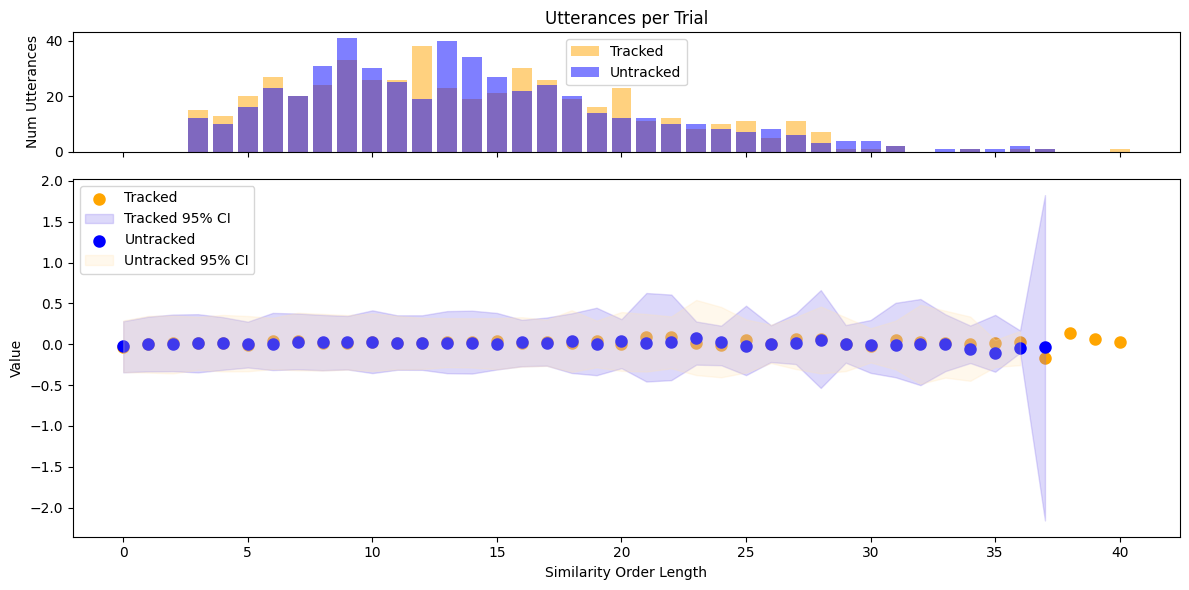

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Zakładam:
# lemmaN_Tracked i lemmaN_UnTracked - listy/arrays z ilością utterances na trial
# długość zgodna z liczbą triali

import numpy as np

merged['Attention2'] =  merged["Attention"].apply(lambda x: 1 if x in [1,2] else 3)


choiceTr = merged['Attention2'] == 1
choiceUnt   = merged['Attention2'] ==  3

choiceTr = merged['Tracking'] == 'TRACKED'
choiceUnt   = merged['Tracking'] =='UNTRACKED'

def visualise_lemmaRuns(lemmaRuns, choiceTr, choiceUnt,merged):
    from scipy.stats import sem, t  

    def parse_array(s):
        s = s.strip()
        # remove brackets if any
        s = s.strip("[]")
        # choose separator
        sep = "," if "," in s else " "
        # convert to float array
        return np.fromstring(s, sep=sep)

    # df["col"] is your Excel column
    arrays = lemmaRuns.apply(parse_array).tolist()


    # Find the max length
    max_len = max(len(a) for a in arrays)

    # Create a 2D array filled with NaN
    arr_2d = np.full((len(arrays), max_len), np.nan)

    # Fill in the rows
    for i, a in enumerate(arrays):
        arr_2d[i, :len(a)] = a

    arr_2d_Tracked = arr_2d[choiceTr]
    arr_2d_UnTracked = arr_2d[choiceUnt]
    # Jeśli masz NaNy w tablicy, używamy nanmean i nanstd

    dd = [len(arr) for arr in arrays]

    full_range = np.arange(2, 43)  # 0…42

    # Tracked
    counts_tr = merged.loc[choiceTr].groupby('lemmaN')['trialNum'].count()
    counts_tr = counts_tr.reindex(full_range, fill_value=np.nan)  # brakujące → NaN

    # Untracked
    counts_unt = merged.loc[choiceUnt].groupby('lemmaN')['trialNum'].count()
    counts_unt = counts_unt.reindex(full_range, fill_value=np.nan)
    counts_tr

    lemmaN_Tracked = counts_tr.values
    lemmaN_UnTracked = counts_unt.values



    mean_tr = np.nanmean(arr_2d_Tracked, axis=0)  # średnia po wierszach
    mean_un = np.nanmean(arr_2d_UnTracked, axis=0)

    # Standard Error (pomijamy NaNy)
    se_tr = np.nanstd(arr_2d_Tracked, axis=0,)
    se_un = np.nanstd(arr_2d_UnTracked, axis=0)

    # 95% Confidence Interval (t-multiplier)
    n_tr = np.sum(~np.isnan(arr_2d_Tracked), axis=0)
    n_un = np.sum(~np.isnan(arr_2d_UnTracked), axis=0)
    tval_tr = t.ppf(0.975, n_tr-1)
    tval_un = t.ppf(0.975, n_un-1)

    ci_tr_lower = mean_tr - tval_tr*se_tr
    ci_tr_upper = mean_tr + tval_tr*se_tr

    ci_un_lower = mean_un - tval_un*se_un
    ci_un_upper = mean_un + tval_un*se_un

    trialN = np.arange(arr_2d_Tracked.shape[1])

    fig, (ax_hist, ax_line) = plt.subplots(2, 1, figsize=(12,6), sharex=True,
                                        gridspec_kw={'height_ratios':[1,3]})

    # --- Histogram górny ---
    ax_hist.bar(trialN, lemmaN_Tracked, color='orange', alpha=0.5, label='Tracked')
    ax_hist.bar(trialN, lemmaN_UnTracked, color='blue', alpha=0.5, label='Untracked')

    ax_hist.set_ylabel("Num Utterances")
    ax_hist.legend()
    ax_hist.set_title("Utterances per Trial")

    # --- Wykres z linią i CI ---
    # Tracked
    ax_line.scatter(trialN, mean_tr, color='orange', linewidth=3, label='Tracked')
    ax_line.fill_between(trialN, ci_tr_lower, ci_tr_upper, color='mediumslateblue', alpha=0.25, label='Tracked 95% CI')

    # Untracked
    ax_line.scatter(trialN, mean_un, color='blue', linewidth=3, label='Untracked')
    ax_line.fill_between(trialN, ci_un_lower, ci_un_upper, color='moccasin', alpha=0.25, label='Untracked 95% CI')

    ax_line.set_xlabel("Similarity Order Length")
    ax_line.set_ylabel("Value")
    ax_line.legend()

    plt.tight_layout()
    plt.show()

visualise_lemmaRuns(lemmaRunsBert, choiceTr, choiceUnt,merged)

In [18]:
merged['Tracking']

0       UNTRACKED
1         TRACKED
2       UNTRACKED
3         TRACKED
4       UNTRACKED
          ...    
1120    UNTRACKED
1121      TRACKED
1122    UNTRACKED
1123      TRACKED
1124    UNTRACKED
Name: Tracking, Length: 1002, dtype: object

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\2510577837.py:68: RuntimeWarning: Mean of empty slice
  mean_un = np.nanmean(arr_2d_UnTracked, axis=0)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


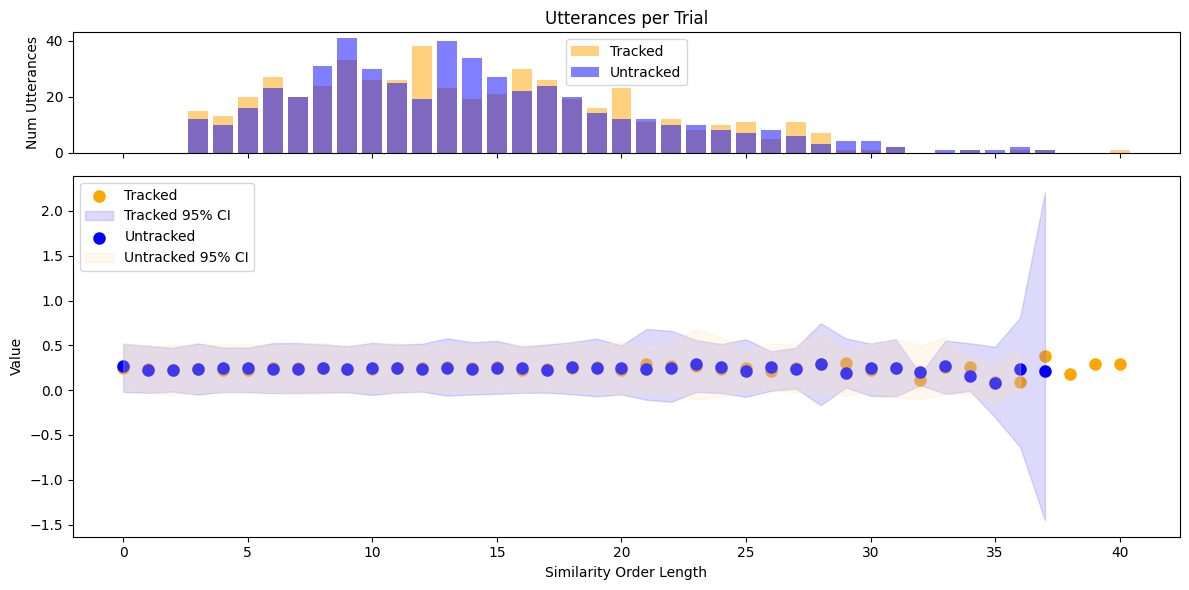

In [19]:
choiceTr = merged['Tracking'] == 'TRACKED'
choiceUnt   = merged['Tracking'] =='UNTRACKED'
visualise_lemmaRuns(lemmaRunsW2v, choiceTr, choiceUnt,merged)

In [20]:
merged.columns

MultiIndex([(                                  '',     '',          ''),
            (                       'MW_Estimate',     '',          ''),
            (                    'GazeDifference',     '',          ''),
            (                    'Pupil_Diameter', 'Mean',  'Left_Eye'),
            (                    'Pupil_Diameter', 'Mean', 'Right_Eye'),
            (                    'Pupil_Diameter',  'Std',  'Left_Eye'),
            (                    'Pupil_Diameter',  'Std', 'Right_Eye'),
            (                    'Pupil_Diameter', 'diff',  'Left_Eye'),
            (                    'Pupil_Diameter', 'diff', 'Right_Eye'),
            (                    'Pupil_Diameter',  'auc',  'Left_Eye'),
            ...
            (     'WordNet_minAggrPath_LengthAvg',     '',          ''),
            (    'WordNet_minAggrPath_Length_Std',     '',          ''),
            (   'WordNet_minAggrPath_Length_Mean',     '',          ''),
            ( 'WordNet_minAggrPath_

In [21]:


ORDER1 = ['Intercept', 'C(Attention2)','lemmaN', 'trialNum']
ORDER2 = ['Intercept', 'C(Attention2)','lemmaN', 'trialNum']
ORDER3 = ['Intercept', 'Tracking','lemmaN', 'trialNum']

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)



mergedTemp = merged[['DS','trialNum','Tracking','MW_Estimate','Attention','lemmaN',
                     'Lemma Sim Run Stds Word2vec' ,'Lemma Sim Run Means Word2vec', 'Lemma Sim Run Means Diff W2v', 'Lemma Sim Run Stds Diff W2v', 
                     'Lemma Sim Run Stds Diff BERT','Lemma Sim Run Means Diff BERT','Lemma Sim Run Stds BERT','LemmaRunMeansBert']];

for analysis in [ 'Lemma Sim Run Stds Word2vec' ,'Lemma Sim Run Means Word2vec', 'Lemma Sim Run Means Diff W2v', 'Lemma Sim Run Stds Diff W2v', 
                     'Lemma Sim Run Stds Diff BERT','Lemma Sim Run Means Diff BERT','Lemma Sim Run Stds BERT','LemmaRunMeansBert']:


    mergedTemp['LemmaSimRun'] = merged[analysis]
    import statsmodels.formula.api as smf
    mergedTemp["Attention2"] = mergedTemp["Attention"].apply(lambda x: 1 if x in [1,2] else 3)

    mergedTemp = mergedTemp[~mergedTemp['LemmaSimRun'].isna()]
    print(" =================== Sim Run Std vs Attention ======================")
    m = smf.mixedlm("LemmaSimRun ~ C(Attention2) + lemmaN +trialNum ", data=mergedTemp,
                    groups="DS",          # random intercept
                    #re_formula="~Tracking",         # adds random slope
                ).fit()
    print(m.summary())   


    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER1 if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER1]
    tbl = tbl[cols].transpose()

    analysis_name = f"{analysis} ~ C(Attention2) + lemmaN +trialNum"
    stats_tables[analysis_name] = tbl



    print(" =================== Sim RUN STD VS MW_Estimate ======================")
    m = smf.mixedlm("LemmaSimRun ~ MW_Estimate  +trialNum  ", data=mergedTemp,
                    groups="DS",          # random intercept
                    #re_formula="~Tracking",         # adds random slope
                ).fit()
    print(m.summary())   

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER2 if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER2]
    tbl = tbl[cols].transpose()

    analysis_name = f"{analysis} ~ MW_Estimate  +trialNum"
    stats_tables[analysis_name] = tbl


    m = smf.mixedlm("LemmaSimRun ~ MW_Estimate + lemmaN  +trialNum ", data=mergedTemp,
                    groups="DS",          # random intercept
                    #re_formula="~Tracking",         # adds random slope
                   ).fit()
    print(m.summary())   

    
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER2 if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER2]
    tbl = tbl[cols].transpose()

    analysis_name = f"{analysis} ~ MW_Estimate + lemmaN  +trialNum"
    stats_tables[analysis_name] = tbl



    print(" =================== Sim RUN STD VS Tracking ======================")
    m = smf.mixedlm("LemmaSimRun ~ Tracking  +trialNum  ", data=mergedTemp,
                    groups="DS",          # random intercept
                    #re_formula="~Tracking",         # adds random slope
                   ).fit()
    print(m.summary())   

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER3 if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER3]
    tbl = tbl[cols].transpose()

    analysis_name = f"{analysis} ~ Tracking  +trialNum"
    stats_tables[analysis_name] = tbl


    m = smf.mixedlm("LemmaSimRun ~ Tracking + lemmaN  +trialNum ", data=mergedTemp,
                    groups="DS",          # random intercept
                    #re_formula="~Tracking",         # adds random slope
                   ).fit()
    print(m.summary())   

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER3 if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER3]
    tbl = tbl[cols].transpose()

    analysis_name = f"{analysis} ~ Tracking  +trialNum"
    stats_tables[analysis_name] = tbl


all_stats_Progression = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P

lvl = 'Variable' if 'Variable' in (all_stats_Progression.index.names or []) else -1
all_stats_Progression = all_stats_Progression[~all_stats_Progression.index.get_level_values(lvl).isin(['Intercept','const'])]

 =================== Sim Run Std vs Attention ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  LemmaSimRun
No. Observations:   1002     Method:              REML       
No. Groups:         26       Scale:               0.0015     
Min. group size:    31       Log-Likelihood:      1811.1133  
Max. group size:    40       Converged:           Yes        
Mean group size:    38.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.100    0.004 24.376 0.000  0.092  0.108
C(Attention2)[T.3] -0.002    0.003 -0.521 0.602 -0.007  0.004
lemmaN              0.001    0.000  6.789 0.000  0.001  0.002
trialNum           -0.000    0.000 -0.142 0.887 -0.000  0.000
DS Var              0.000    0.000                           

 =================== Sim RUN STD VS MW_Estimate ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LemmaSimRun
No. Observations: 1002    Method:             REML       
No. Groups:       26      Scale:              0.0015     
Min. group size:  31      Log-Likelihood:     1800.5160  
Max. group size:  40      Converged:          Yes        
Mean group size:  38.5                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.122    0.003 39.670 0.000  0.116  0.128
MW_Estimate     0.002    0.001  1.887 0.059 -0.000  0.005
trialNum       -0.000    0.000 -0.363 0.717 -0.000  0.000
DS Var          0.000    0.001                           



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LemmaSimRun
No. Observations: 1002    Method:             REML       
No. Groups:       26      Scale:              0.0025     
Min. group size:  31      Log-Likelihood:     1550.2768  
Max. group size:  40      Converged:          Yes        
Mean group size:  38.5                                   
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      -0.002    0.006 -0.264 0.792 -0.013  0.010
MW_Estimate     0.005    0.002  2.855 0.004  0.001  0.008
lemmaN          0.001    0.000  3.600 0.000  0.000  0.002
trialNum       -0.000    0.000 -1.075 0.283 -0.000  0.000
DS Var          0.000    0.001                           

 =================== Sim RUN STD VS Tracking ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   LemmaSimRun
No. Observations:    1002      Method:               REML       
No. Groups:          26        Scale:                0.0025     
Min. group size:     31        Log-Likelihood:       1546.4979  
Max. group size:     40        Converged:            Yes        
Mean group size:     38.5                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.015    0.004  3.598 0.000  0.007  0.023
Tracking[T.UNTRACKED] -0.002    0.003 -0.641 0.521 -0.008  0.004
trialNum              -0.000    0.000 -0.823 0.410 -0.000  0.000
DS Var                 0.000    0.001                           

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:  

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [22]:
stats_tables

{'Lemma Sim Run Stds Word2vec ~ C(Attention2) + lemmaN +trialNum':                         Coef          z              P       Cf1       Cf2
 Intercept           0.100410  24.375610  3.103139e-131  0.092336  0.108483
 lemmaN              0.001379   6.789049   1.128754e-11  0.000981  0.001777
 trialNum           -0.000015  -0.141645   8.873605e-01 -0.000222  0.000192
 C(Attention2)[T.3] -0.001566  -0.521117   6.022851e-01 -0.007456  0.004324,
 'Lemma Sim Run Stds Word2vec ~ MW_Estimate  +trialNum':                  Coef          z         P       Cf1       Cf2
 Intercept    0.122185  39.669954  0.000000  0.116148  0.128221
 trialNum    -0.000039  -0.362546  0.716944 -0.000248  0.000171
 MW_Estimate  0.002342   1.886889  0.059175 -0.000091  0.004774,
 'Lemma Sim Run Stds Word2vec ~ MW_Estimate + lemmaN  +trialNum':                  Coef          z              P       Cf1       Cf2
 Intercept    0.100856  24.309722  1.547140e-130  0.092725  0.108988
 lemmaN       0.001344   6.580551   4

### Main Statistical Checks

Here - it is to Reassure Us that The Attention-like MW 

To see whether we can replicate our previous findings but with the usage of Labeled Human Utterances:
1) MS_Estimate ~ Attention + Trial Number Controll
2) Attention   ~ MW_Tracking


In [23]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt

from analysisFunctions import plotTrialTrack,diffRainPlot

import seaborn as sns
from statannotations.Annotator import Annotator
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import ranksums### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

def annotBoxPlots(df,meas,target,custom_cmap,AnName = None):
    fig, ax = plt.subplots(figsize=(12,8))
    plt.title(f"{target} vs {meas}")

    customCols = custom_cmap(np.linspace(0,256,len(list(df[target].unique())),dtype=int))
    ax = sns.boxplot(x=target, y=meas, data=df, palette=customCols, showfliers=False)
    sns.stripplot(x=target, y=meas, data=df, color="black", alpha=0.35)

    pairs = []
    cAnn = []
    for i in list(df[target].unique()):
        for j in  list(df[target].unique()):
            if i == j or (j,i) in pairs:
                continue
            pairs.append((i,j))
            res = ranksums(list(df[df[target]== i][meas]),list(df[df[target] == j][meas]))
            if res[1] <0.001:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) ***")
            elif res[1] <0.01:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) **")
            elif res[1] <0.05:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) *")
            elif res[1] >=0.05:
                cAnn.append(f"s: {res[0]:1.4f} p ({res[1]:1.4f}) ")

    pairsDf = pd.DataFrame({'pairs': pairs, 'anns': cAnn})
    pairsDf = pairsDf.sort_values(by='pairs', axis=0)

    annot = Annotator(ax, list(pairsDf['pairs']), data=df, x=target, y=meas)
    # If you already have your own labels:
    annot.configure(text_format="simple")
    annot.set_custom_annotations(list(pairsDf['anns']))
    annot.annotate()

    if AnName == None:
        AnName = meas
    ax.set_ylabel(AnName)
    ax.set_title(f"{AnName} vs {target}")

    plt.tight_layout()
    return fig

1 vs. 2: s: -5.3850 p (0.0000) ***
2 vs. 3: s: 7.4037 p (0.0000) ***
3 vs. 4: s: 0.4349 p (0.6636) 
2 vs. 4: s: -1.3279 p (0.1842) 
1 vs. 3: s: 10.8370 p (0.0000) ***
1 vs. 4: s: -2.2756 p (0.0229) *


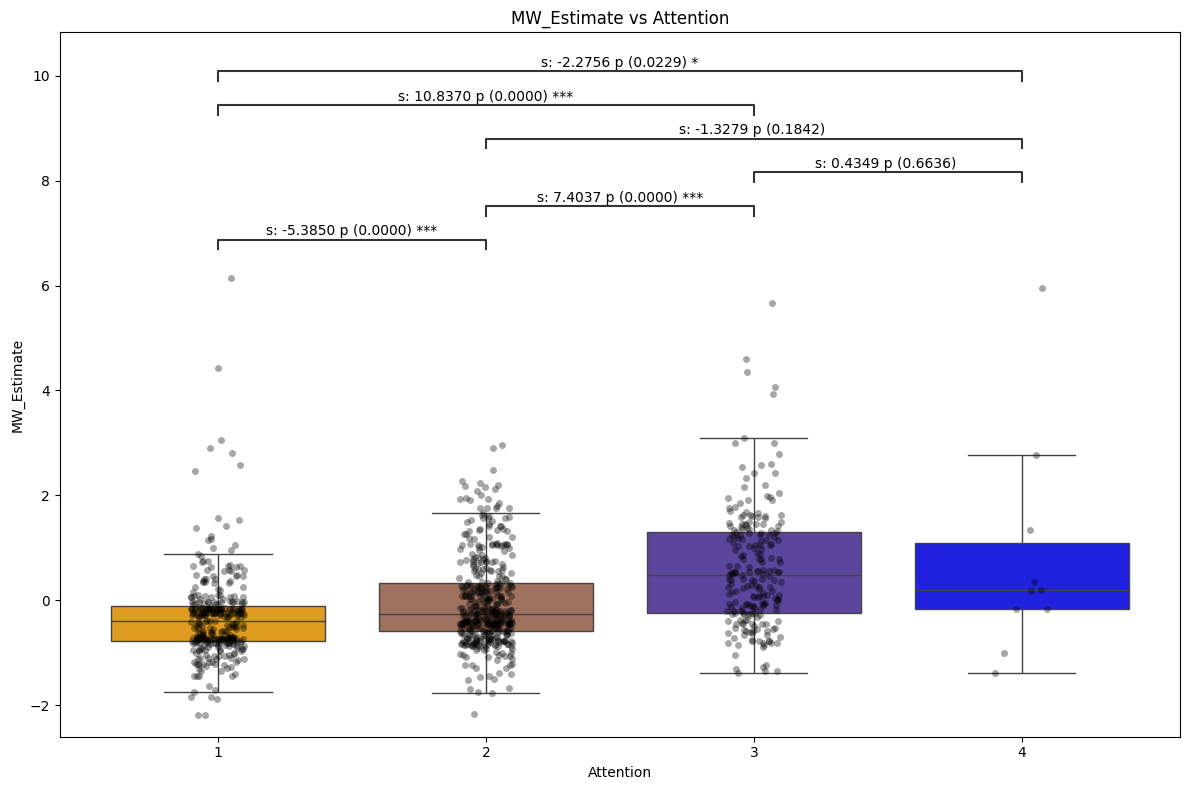

In [24]:
### Create a Color Palette:
custom_cmap = LinearSegmentedColormap.from_list(
    "orange_blue", ["orange", "blue"]
)
colors = custom_cmap(np.linspace(0,256,4,dtype=int))

pdf_path = os.path.join(savePathFeatures, "Checks.pdf")
pdfs_Check = PdfPages(pdf_path)


fig1 = annotBoxPlots(merged,'MW_Estimate','Attention',custom_cmap)
pdfs_Check.savefig(fig1)
plt.show(fig1)

In [25]:
ranksums(merged[merged['Tracking'] == 'UNTRACKED']['Attention'],merged[merged['Tracking'] == 'TRACKED']['Attention'])

RanksumsResult(statistic=2.9731486652611174, pvalue=0.0029476164486363365)

TRACKED_Att1 vs. TRACKED_Att3: s: 2.5988 p (0.0094) **
UNTRACKED_Att1 vs. UNTRACKED_Att3: s: 0.4758 p (0.6342) 
UNTRACKED_Att3 vs. TRACKED_Att1: s: -1.7752 p (0.0759) 
UNTRACKED_Att1 vs. TRACKED_Att1: s: -1.2262 p (0.2201) 
UNTRACKED_Att3 vs. TRACKED_Att3: s: 1.0432 p (0.2969) 
UNTRACKED_Att1 vs. TRACKED_Att3: s: 1.2536 p (0.2100) 


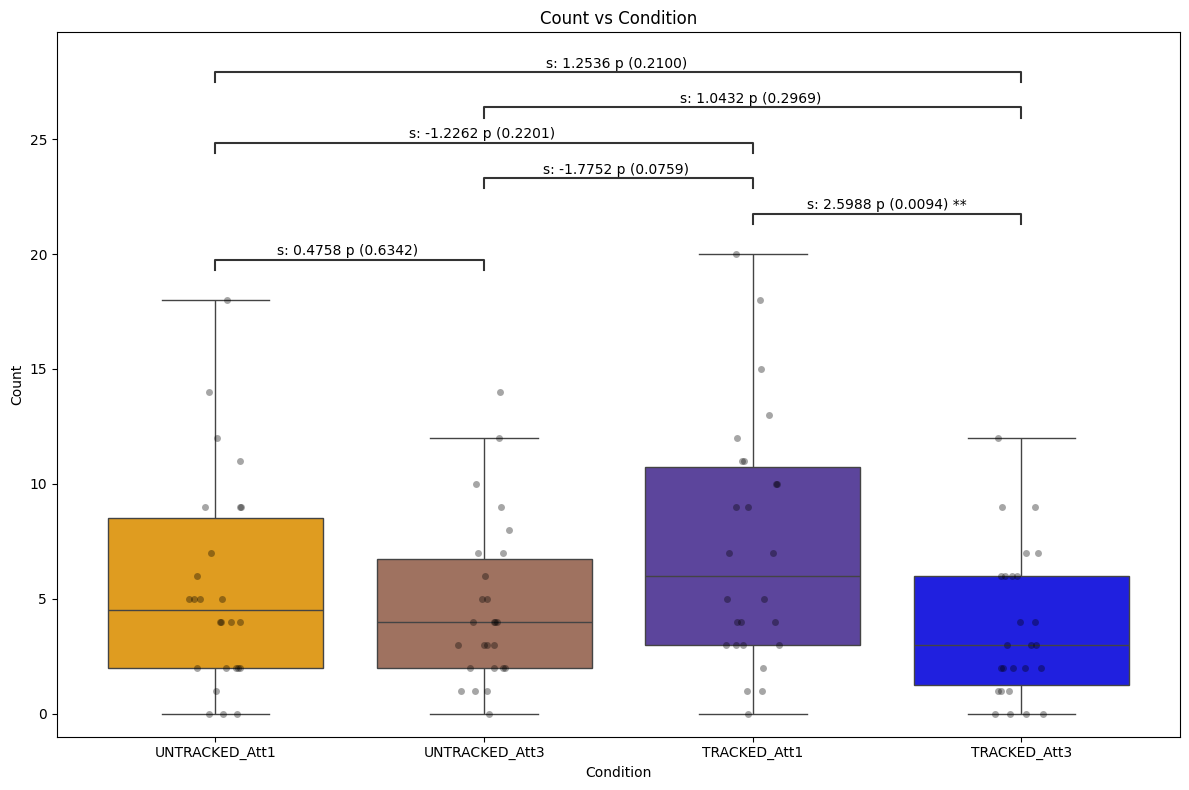

In [26]:
subj_counts = pd.DataFrame({
    'UNTRACKED_Att1': merged[(merged['Tracking'] == 'UNTRACKED') & (merged['Attention'] == 1)].groupby('Subject')['Attention'].count(),
    'UNTRACKED_Att3': merged[(merged['Tracking'] == 'UNTRACKED') & (merged['Attention'] == 3)].groupby('Subject')['Attention'].count(),
    'TRACKED_Att1':   merged[(merged['Tracking'] == 'TRACKED')   & (merged['Attention'] == 1)].groupby('Subject')['Attention'].count(),
    'TRACKED_Att3':   merged[(merged['Tracking'] == 'TRACKED')   & (merged['Attention'] == 3)].groupby('Subject')['Attention'].count()
}).fillna(0).astype(int)

# Reshape for plotting
subj_counts_long = subj_counts.reset_index().melt(id_vars='Subject', var_name='Condition', value_name='Count')

# Example usage:
fig = annotBoxPlots(subj_counts_long, 'Count', 'Condition', custom_cmap)
plt.show(fig)

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Attention 
No. Observations:    1002      Method:               REML      
No. Groups:          26        Scale:                0.4676    
Min. group size:     31        Log-Likelihood:       -1078.6178
Max. group size:     40        Converged:            Yes       
Mean group size:     38.5                                      
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.696    0.081 20.978 0.000  1.538  1.855
Tracking[T.UNTRACKED] 0.147    0.043  3.392 0.001  0.062  0.231
trialNum              0.007    0.002  3.577 0.000  0.003  0.010
DS Var                0.109    0.051                           

UNTRACKED vs. TRACKED: s: 2.9731 p (0.0029) **


c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


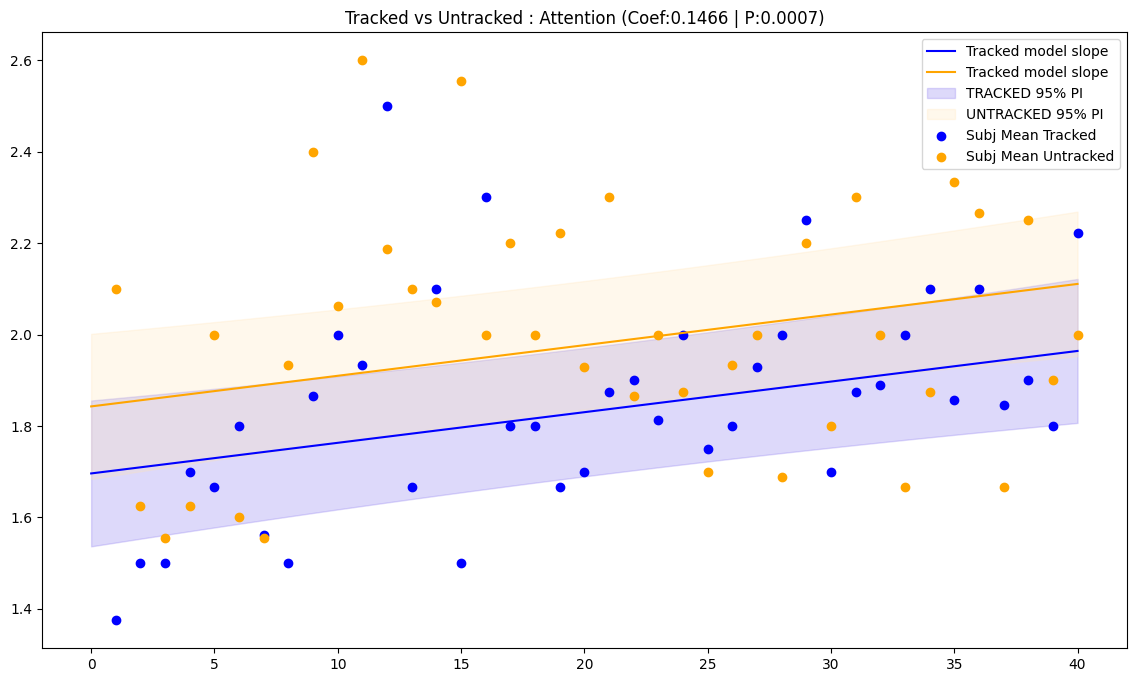

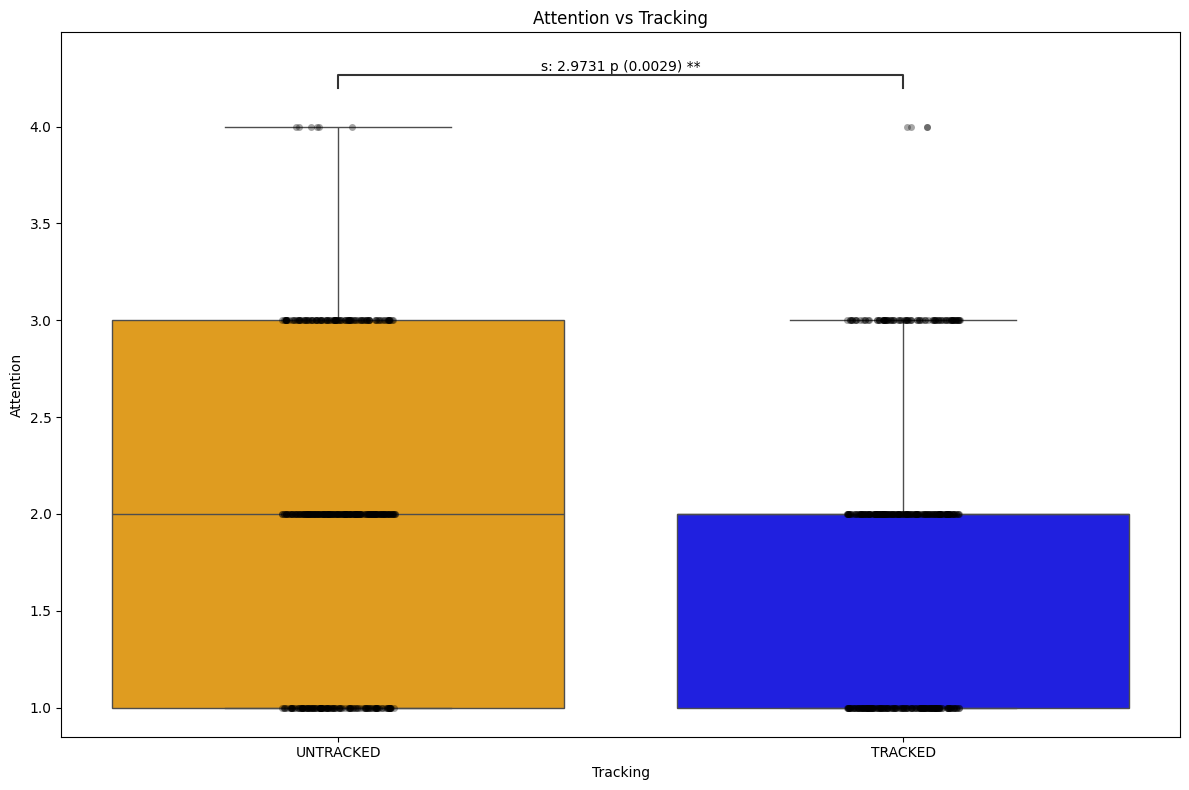

In [27]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt

from analysisFunctions import plotTrialTrack

### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

m = smf.mixedlm("Attention ~ Tracking+trialNum ", data=merged[['DS','trialNum','Tracking','MW_Estimate','Attention']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'Attention',merged,ax,titl=f"Tracked vs Untracked : Attention (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )


pdfs_Check.savefig(fig)

fig1 = annotBoxPlots(merged,'Attention','Tracking',custom_cmap)
pdfs_Check.savefig(fig1)

pdfs_Check.close()


In [28]:

proportions = merged.groupby(['DS', 'Tracking'])['Attention'].value_counts(normalize=True).unstack()

tracked_proportions = proportions.loc[pd.IndexSlice[:, 'TRACKED'], :].fillna(0)
untracked_proportions = proportions.loc[pd.IndexSlice[:, 'UNTRACKED'], :].fillna(0)
from scipy.stats import wilcoxon### Model Checks: 

wilcoxon(tracked_proportions[3].values,untracked_proportions[3].values)

WilcoxonResult(statistic=85.0, pvalue=0.10672015761553805)

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  1002     Method:              REML       
No. Groups:        26       Scale:               0.8646     
Min. group size:   31       Log-Likelihood:      -1358.1174 
Max. group size:   40       Converged:           Yes        
Mean group size:   38.5                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.437    0.074 -5.908 0.000 -0.583 -0.292
C(Attention)[T.2]  0.286    0.078  3.678 0.000  0.133  0.438
C(Attention)[T.3]  0.921    0.103  8.960 0.000  0.720  1.122
C(Attention)[T.4]  1.090    0.302  3.614 0.000  0.499  1.681
trialNum           0.006    0.003  2.175 0.030  0.001  0.011
DS Var             0.001    0.009                           



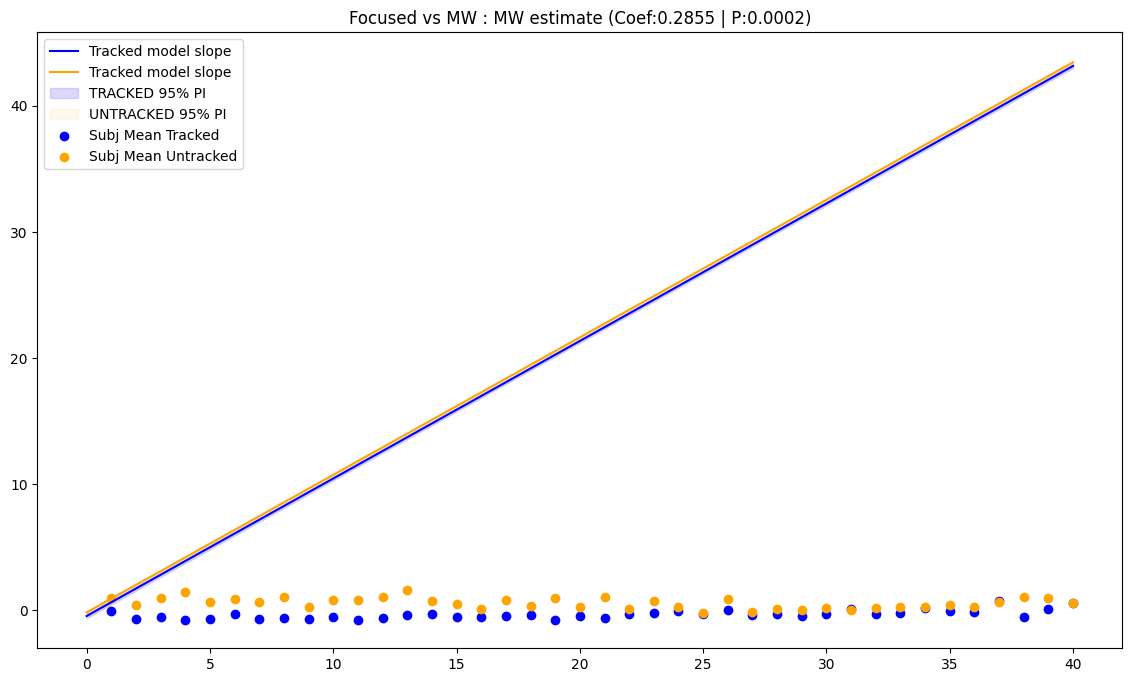

In [29]:
# Fit the mixed effects model
m = smf.mixedlm("MW_Estimate ~ C(Attention) + trialNum", data=merged,
                groups="DS",  # Random intercept
                ).fit()


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',merged,ax,titl=f"Focused vs MW : MW estimate (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",paramNum=[0,1,3],anlysisName = 'Attention',firstContrast=1,lastContrast =3 )
print(m.summary())   
fig.savefig(os.path.join(savePathFeatures,'plot.png'))

## (1) Statistical Analysis of: MW_Estimate Predictions:


Here we Predict and Place in a single DataFrame A Simple Predictions of MW_Estimate by Utterance Features:
Additionally With Controll for Trial Number (and Possibly Tracking~Untracking) 

This Aims at seeing which Lexical Variability Features can Predict MW_Estimate (And thus in high vs Low MW Estimate are different)

In [30]:

def plot_pupil_vs_mw_Att(m, currentDf, ind, ax=None,meas='Pupil',target='MW_Estimate',split='Attention',meas1=1,meas2=2):
    """
    Plot Pupil vs MW_Estimate with linear fits for TRACKED and UNTRACKED groups.
    
    Parameters:
    - m: Fitted mixed effects model.
    - currentDf: DataFrame containing the data.
    - ind: Tuple indicating the current column (e.g., ('Pupil', 'Diameter')).
    - ax: Matplotlib Axes object. If None, a new figure will be created.
    """
    # Create a new figure and axis if no Axes object is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define linear functions for TRACKED and UNTRACKED
    # Get Model Values and lambdas for 
    if split != None:
        mnames = ['Intercept'] + [i for i in m.params.keys() if split in  i]
        mvals = [0] + [m.params[i] for i in m.params.keys() if split in  i]
        linfuns = [lambda x, v=val: m.params[m.params.keys()[0]] + m.params[target] * x + v for val in mvals]
   
        #Get Values of Split:
        svals = currentDf[split].unique()
        svals.sort()

        ### Create a Color Palette:
        custom_cmap = LinearSegmentedColormap.from_list(
            "orange_blue", ["orange", "blue"]
        )

        colors = custom_cmap(np.linspace(0,256,4,dtype=int))

        # Create a custom colormap from orange to blue


        for i,sv in enumerate(svals):
        # Scatter plot for TRACKED and UNTRACKED
            print(mnames[i])
            ax.scatter(currentDf[currentDf[split] == sv][target],
                    currentDf[currentDf[split] == sv][meas], color=colors[i],
                    label=f"{mnames[i]} (Coef: {m.params[mnames[i]]:1.3f}) Pval: {m.pvalues[mnames[i]]:1.4f}")
       
            Lab = "".join([" " for j in mnames[i]])
            ax.plot(currentDf[target], linfuns[i](currentDf[target]), color=colors[i])
    else: 
        linfun =lambda x: m.params[m.params.keys()[0]] + m.params[m.params.keys()[1]] * x 

        ax.scatter(currentDf[target],
                currentDf[meas],
                color='orange', label=f"Trial: (Coef: {m.params[m.params.keys()[2]]:1.4f} | P: {m.pvalues[m.params.keys()[2]]:1.4f})")

        ax.plot(currentDf[target], linfun(currentDf[target]), 'b--', label="Tracked Fit")
    # Add labels, title, and legend
    ax.set_xlabel('MW Estimate')
    ax.set_ylabel(f"{meas} Measure: {ind[0]} // {ind[1]}")
    ax.set_title(f"{ind[0]} // {ind[1]}: (Coef: {m.params[m.params.keys()[meas2]]:1.4f} P: {m.pvalues[m.params.keys()[meas2]]:1.4f})")
    ax.legend()

    # Add a suptitle if it's a standalone plot
    if ax is None:
        plt.suptitle(f"MW Estimate vs {meas} Measure")
        plt.show()




def write_sheet(all_stats, sheet_name, writer):
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    if isinstance(all_stats.columns, pd.MultiIndex):
        pvalCol = all_stats.xs('P', axis=1, level=1);
    else:
        pvalCol = all_stats["P"];
    for r, pval in enumerate(pvalCol, start=start_row):
        try:
            if pd.notna(pval) and float(pval) <= 0.05:
                ws.set_row(r, None, bold)
        except Exception:
            pass


### Predicting Mind Wandering by Semantic Featuures while controlling for TRACKED

In [31]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic_Tr.pdf")
pdfs_MWES_Tr = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]','Utterance', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v',],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("MW_Estimate ~ Utterance + Tracking+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=True,meas1=3,meas2=2)

    pdfs_MWES_Tr.savefig(fig)
    plt.close(fig)

pdfs_MWES_Tr.close()
all_stats_MWES_Tr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES_Tr.index.names or []) else -1
all_stats_MWES_Tr = all_stats_MWES_Tr[~all_stats_MWES_Tr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES_Tr

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3809990263.py:15: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v',],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Personal Verb Count =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    985       Method:               REML       
No. Groups:          26        Scale:                0.9389     
Min. group size:     31        Log-Likelihood:       -1377.1839 
Max. group size:     40        Converged:            No         
Mean group size:     37.9                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.441    0.069 -6.351 0.000 -0.577 -0.305
Tracking[T.UNTRACKED]  0.240    0.062  3.889 0.000  0.119  0.361
Utterance              0.084    0.003 25.108 0.000  0.078  0.091
trialNum               0.008    0.003  2.966 0.003  0.003  0.013
DS Var                 0.000                                    



======== Test for MW Estimate vs pPr

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


...

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    998       Method:               REML       
No. Groups:          26        Scale:                0.9532     
Min. group size:     31        Log-Likelihood:       -1404.9081 
Max. group size:     40        Converged:            Yes        
Mean group size:     38.4                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.535    0.097 -5.540 0.000 -0.725 -0.346
Tracking[T.UNTRACKED]  0.286    0.062  4.632 0.000  0.165  0.408
Utterance              0.006    0.002  3.710 0.000  0.003  0.010
trialNum               0.008    0.003  2.987 0.003  0.003  0.013
DS Var                 0.000                                    



======== Test for MW Estimate vs Wor

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    994       Method:               REML       
No. Groups:          26        Scale:                0.9134     
Min. group size:     31        Log-Likelihood:       -1374.9929 
Max. group size:     40        Converged:            No         
Mean group size:     38.2                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.067    0.178  0.379 0.704 -0.281  0.416
Tracking[T.UNTRACKED]  0.304    0.061  5.020 0.000  0.186  0.423
Utterance             -0.122    0.057 -2.143 0.032 -0.234 -0.010
trialNum               0.007    0.003  2.575 0.010  0.002  0.012
DS Var                 0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 15.317946
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Doc

Coef  \
analysis                                 stat                              
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.240258   
                                         Utterance              0.084062   
                                         trialNum               0.007919   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]  0.277500   
                                         Utterance              0.169132   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_Weight    Utterance              0.006462   
                                         trialNum               0.008008   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]  0.304417   
                                         Utterance             -0.122106   
                                         trialNum               0.006768   

                                                                        z  \
analysis                                 stat                               
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]   3.888768   
                                         Utterance              25.108409   
                                         trialNum                2.965650   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]   4.472290   
                                         Utterance               4.774877   
...                                                                   ...   
MW_Estimate vs WordNet_Steiner_Weight    Utterance               3.709901   
                                         trialNum                2.986977   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]   5.019870   
                                         Utterance              -2.142554   
                                         trialNum                2.575034   

                                                                            P  \
analysis                                 stat                                   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]   1.007542e-04   
                                         Utterance              4.025508e-139   
                                         trialNum                3.020443e-03   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]   7.738649e-06   
                                         Utterance               1.798167e-06   
...                                                                       ...   
MW_Estimate vs WordNet_Steiner_Weight    Utterance               2.073403e-04   
                                         trialNum                2.817513e-03   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]   5.170658e-07   
                                         Utterance               3.214892e-02   
                                         trialNum                1.002301e-02   

                                                                     Cf1  \
analysis                                 stat                              
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.119166   
                                         Utterance              0.077500   
                                         trialNum               0.002685   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]  0.155887   
                                         Utterance              0.099708   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_Weight    Utterance              0.003048   
                                         trialNum               0.002753   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]  0.185560   
                                         Utterance             -0.233807   
                                         trialNum               0.001617   

                                  

In [32]:
dfAnalysis['Lemma Embeddings TF_IDF ']

20     1.0
0      1.0
31     1.0
11     1.0
33     1.0
      ... 
616    1.0
637    1.0
617    1.0
639    1.0
619    1.0
Name: Lemma Embeddings TF_IDF , Length: 1125, dtype: float64

### Predicting Mind Wandering by Semantic Features PLAIN

In [33]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic.pdf")
pdfs_MWES = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'MW_Estimate', 'Utterance', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind,'lemmaN']]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance','lemmaN']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ MW_Estimate +trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=False,meas1=2,meas2=1)

    pdfs_MWES.savefig(fig)
    plt.close(fig)

pdfs_MWES.close()
all_stats_MWES = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES.index.names or []) else -1
all_stats_MWES = all_stats_MWES[~all_stats_MWES.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\4157749973.py:13: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Personal Verb Count =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 985     Method:             REML      
No. Groups:       26      Scale:              1.8891    
Min. group size:  31      Log-Likelihood:     -1760.7139
Max. group size:  40      Converged:          Yes       
Mean group size:  37.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.205    0.250  8.832 0.000  1.715  2.694
MW_Estimate    0.301    0.044  6.782 0.000  0.214  0.388
trialNum      -0.006    0.004 -1.545 0.122 -0.013  0.002
DS Var         1.415    0.306                           



======== Test for MW Estimate vs pPronCount =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable:

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 988     Method:             REML     
No. Groups:       26      Scale:              0.0024   
Min. group size:  30      Log-Likelihood:     1557.9818
Max. group size:  40      Converged:          Yes      
Mean group size:  38.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.150    0.004 40.675 0.000  0.143  0.157
MW_Estimate   0.002    0.002  1.109 0.268 -0.001  0.005
trialNum      0.000    0.000  0.279 0.780 -0.000  0.000
DS Var        0.000    0.001                           



======== Test for MW Estimate vs LemmaRunMeansBert =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 981     Method:             REML     
No. Groups:       26      Scale:              0.0308   
Min. group size:  31      Log-Likelihood:     269.4407 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.7                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.391    0.022 17.580 0.000  0.348  0.435
MW_Estimate  -0.021    0.006 -3.678 0.000 -0.032 -0.010
trialNum      0.001    0.000  2.071 0.038  0.000  0.002
DS Var        0.010    0.017                           



======== Test for MW Estimate vs WordNet_minAggrPath_Length =======

          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Utterance 
No. Observations:   996     Method:           

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 981     Method:             REML     
No. Groups:       26      Scale:              0.0142   
Min. group size:  29      Log-Likelihood:     651.7671 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.7                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.258    0.014 18.291 0.000  0.230  0.286
MW_Estimate  -0.012    0.004 -3.109 0.002 -0.019 -0.004
trialNum      0.001    0.000  1.594 0.111 -0.000  0.001
DS Var        0.004    0.010                           



======== Test for MW Estimate vs WordNet_minAggrPath_Length_MeanAvg =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 977     Method:         

Coef         z  \
analysis                                 stat                              
MW_Estimate vs Personal Verb Count       MW_Estimate  0.301155  6.781534   
                                         trialNum    -0.005878 -1.544870   
MW_Estimate vs pPronCount                MW_Estimate  0.103364  4.918404   
                                         trialNum    -0.001179 -0.650988   
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  0.001735  1.108510   
...                                                        ...       ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum    -0.044202 -0.894424   
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  1.620451  4.125664   
                                         trialNum    -0.029837 -0.881098   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate -0.034079 -2.041756   
                                         trialNum     0.001132  0.805772   

                                                                 P       Cf1  \
analysis                                 stat                                  
MW_Estimate vs Personal Verb Count       MW_Estimate  1.189061e-11  0.214117   
                                         trialNum     1.223777e-01 -0.013335   
MW_Estimate vs pPronCount                MW_Estimate  8.725248e-07  0.062174   
                                         trialNum     5.150541e-01 -0.004729   
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  2.676417e-01 -0.001332   
...                                                            ...       ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum     3.710948e-01 -0.141062   
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  3.696661e-05  0.850629   
                                         trialNum     3.782650e-01 -0.096208   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate  4.117576e-02 -0.066793   
                                         trialNum     4.203744e-01 -0.001621   

                                                           Cf2  
analysis                                 stat                   
MW_Estimate vs Personal Verb Count       MW_Estimate  0.388193  
                                         trialNum     0.001579  
MW_Estimate vs pPronCount                MW_Estimate  0.144554  
                                         trialNum     0.002371  
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  0.004802  
...                                                        ...  
MW_Estimate vs WordNet_Steiner_NodeN     trialNum     0.052658  
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  2.390273  
                                         trialNum     0.036534  
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate -0.001365  
                                         trialNum     0.003884  

[102 rows x 5 columns]

### Utterance ~Mind Wandering + lemmaN

In [34]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "Semantic_MW_Est_Contr.pdf")
pdfs_MWESCtr = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'MW_Estimate', 'lemmaN','Utterance', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind,'lemmaN']]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance','lemmaN']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ MW_Estimate+ lemmaN +trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=False,meas1=2,meas2=1)

    pdfs_MWES.savefig(fig)
    plt.close(fig)

pdfs_MWESCtr.close()
all_stats_MWESctr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWESctr.index.names or []) else -1
all_stats_MWESctr = all_stats_MWESctr[~all_stats_MWESctr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWESctr



======== Test for MW Estimate vs Personal Verb Count =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\1615008077.py:13: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 985     Method:             REML      
No. Groups:       26      Scale:              1.7051    
Min. group size:  31      Log-Likelihood:     -1711.4155
Max. group size:  40      Converged:          Yes       
Mean group size:  37.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.788    0.256  3.082 0.002  0.287  1.290
MW_Estimate    0.247    0.042  5.824 0.000  0.164  0.331
lemmaN         0.089    0.008 10.592 0.000  0.073  0.105
trialNum      -0.005    0.004 -1.298 0.194 -0.012  0.002
DS Var         1.051    0.241                           



======== Test for MW Estimate vs pPronCount =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Uttera

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 988     Method:             REML     
No. Groups:       26      Scale:              0.0023   
Min. group size:  30      Log-Likelihood:     1565.3156
Max. group size:  40      Converged:          Yes      
Mean group size:  38.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.127    0.006 23.061 0.000  0.116  0.138
MW_Estimate   0.001    0.002  0.526 0.599 -0.002  0.004
lemmaN        0.001    0.000  5.447 0.000  0.001  0.002
trialNum      0.000    0.000  0.391 0.696 -0.000  0.000
DS Var        0.000    0.001                           



======== Test for MW Estimate vs LemmaRunMeansBert =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 981     Method:             REML     
No. Groups:       26      Scale:              0.0084   
Min. group size:  29      Log-Likelihood:     918.3951 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.7                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.496    0.011  44.211 0.000  0.474  0.518
MW_Estimate -0.002    0.003  -0.828 0.408 -0.008  0.003
lemmaN      -0.015    0.001 -27.233 0.000 -0.016 -0.014
trialNum     0.000    0.000   1.454 0.146 -0.000  0.001
DS Var       0.000    0.002                            



======== Test for MW Estimate vs WordNet_minAggrPath_Length_MeanAvg =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 977     Method:             REML     
No. Groups:       26      Scale:              0.0421   
Min. group size:  29      Log-Likelihood:     122.9407 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.6                                 
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    1.517    0.028  54.494 0.000  1.462  1.571
MW_Estimate -0.005    0.007  -0.739 0.460 -0.018  0.008
lemmaN      -0.048    0.001 -37.210 0.000 -0.051 -0.046
trialNum     0.001    0.001   1.947 0.052 -0.000  0.002
DS Var       0.004    0.008                            



======== Test for MW Estimate vs WordNet_Steiner_EdgeN =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance

Coef          z  \
analysis                                 stat                               
MW_Estimate vs Personal Verb Count       MW_Estimate  0.247477   5.824027   
                                         lemmaN       0.088983  10.592297   
                                         trialNum    -0.004693  -1.297631   
MW_Estimate vs pPronCount                MW_Estimate  0.088070   4.232843   
                                         lemmaN       0.024695   6.164973   
...                                                        ...        ...   
MW_Estimate vs WordNet_Steiner_Weight    lemmaN       2.134412  59.789653   
                                         trialNum    -0.003501  -0.204799   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate -0.010969  -0.686926   
                                         lemmaN      -0.030758 -10.853102   
                                         trialNum     0.000879   0.660442   

                                                                 P       Cf1  \
analysis                                 stat                                  
MW_Estimate vs Personal Verb Count       MW_Estimate  5.744636e-09  0.164193   
                                         lemmaN       3.235518e-26  0.072518   
                                         trialNum     1.944140e-01 -0.011781   
MW_Estimate vs pPronCount                MW_Estimate  2.307560e-05  0.047290   
                                         lemmaN       7.049525e-10  0.016844   
...                                                            ...       ...   
MW_Estimate vs WordNet_Steiner_Weight    lemmaN       0.000000e+00  2.064444   
                                         trialNum     8.377293e-01 -0.037009   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate  4.921292e-01 -0.042265   
                                         lemmaN       1.927700e-27 -0.036313   
                                         trialNum     5.089699e-01 -0.001729   

                                                           Cf2  
analysis                                 stat                   
MW_Estimate vs Personal Verb Count       MW_Estimate  0.330760  
                                         lemmaN       0.105449  
                                         trialNum     0.002395  
MW_Estimate vs pPronCount                MW_Estimate  0.128849  
                                         lemmaN       0.032546  
...                                                        ...  
MW_Estimate vs WordNet_Steiner_Weight    lemmaN       2.204381  
                                         trialNum     0.030006  
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate  0.020328  
                                         lemmaN      -0.025204  
                                         trialNum     0.003487  

[153 rows x 5 columns]

In [35]:
import statsmodels.formula.api as smf

res = smf.ols('MW_Estimate ~ Utterance', data=currentDf).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:            MW_Estimate   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.484
Date:                Sat, 07 Feb 2026   Prob (F-statistic):             0.0345
Time:                        11:18:14   Log-Likelihood:                -1379.4
No. Observations:                 994   AIC:                             2763.
Df Residuals:                     992   BIC:                             2773.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3583      0.170      2.110      0.0

In [36]:
currentDf = merged[['trialNum','DS','MW_Estimate','Tracking','Personal Verb Count']]
currentDf['Utterance'] = currentDf['Personal Verb Count']

m = smf.mixedlm("Utterance ~ Tracking", data=currentDf,
                groups="DS",  # Random intercept
                ).fit()
m.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM   Dependent Variable:   Utterance 
No. Observations:   1002      Method:               REML      
No. Groups:         26        Scale:                2.4609    
Min. group size:    31        Log-Likelihood:       -1917.7668
Max. group size:    40        Converged:            Yes       
Mean group size:    38.5                                      
--------------------------------------------------------------
                      Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             2.059    0.274 7.501 0.000  1.521  2.597
Tracking[T.UNTRACKED] 0.246    0.099 2.480 0.013  0.052  0.440
DS Var                1.831    0.346                          
==============================================================

"""

In [37]:
dfAnalysis['Lemma Embeddings TF_IDF ']

20     1.0
0      1.0
31     1.0
11     1.0
33     1.0
      ... 
616    1.0
637    1.0
617    1.0
639    1.0
619    1.0
Name: Lemma Embeddings TF_IDF , Length: 1125, dtype: float64

### (2) Test whether the MW_estimates are dependent on Utterance with controll for Attention

This is a simple Check - to further ascertain the relation between the attentionality in Utterances and MW_estimates - ideally we could totally omit that, but it serves as a controll 

IF Given Feature cannot Distinguish between Attentionality AND MW_Estimates-  then it should be removed


**This Particular Analysis is not very informative - It can be used to see whether there is an indication of mediation**

In [38]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic_Att.pdf")
pdfs_MWES_Att = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]',
         'Utterance', 'trialNum']



for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Attention','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate','Attention', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate','Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("MW_Estimate ~ Utterance + C(Attention)+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    # ---- Plots 
    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw_Att(m, currentDf,  [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',split='Attention',meas1=5,meas2=4)

    pdfs_MWES_Att.savefig(fig)
    plt.close(fig)

pdfs_MWES_Att.close()

all_stats_MWES_Att = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES_Att.index.names or []) else -1
all_stats_MWES_Att = all_stats_MWES_Att[~all_stats_MWES_Att.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES_Att

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\1893517749.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):




======== Test for MW Estimate vs Personal Verb Count =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  985      Method:              REML       
No. Groups:        26       Scale:               0.8479     
Min. group size:   31       Log-Likelihood:      -1332.0206 
Max. group size:   40       Converged:           Yes        
Mean group size:   37.9                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.508    0.087 -5.848 0.000 -0.678 -0.338
C(Attention)[T.2]  0.262    0.078  3.362 0.001  0.109  0.414
C(Attention)[T.3]  0.915    0.098  9.305 0.000  0.722  1.108
C(Attention)[T.4]  1.269    0.338  3.756 0.000  0.607  1.931
Utterance          0.039    0.021  1.887 0.059 -0.002  0.080
trialNum           0.006    0.003  2.224 0.026  0.001  0.011
DS Var             0.009    0.014   

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  1000     Method:              REML       
No. Groups:        26       Scale:               0.8586     
Min. group size:   31       Log-Likelihood:      -1359.3843 
Max. group size:   40       Converged:           Yes        
Mean group size:   38.5                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.536    0.109 -4.931 0.000 -0.749 -0.323
C(Attention)[T.2]  0.280    0.078  3.599 0.000  0.127  0.432
C(Attention)[T.3]  0.925    0.100  9.298 0.000  0.730  1.121
C(Attention)[T.4]  1.081    0.302  3.582 0.000  0.489  1.672
Utterance          0.002    0.001  1.116 0.264 -0.001  0.005
trialNum           0.006    0.003  2.264 0.024  0.001  0.011
DS Var             0.005    0.011   

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  MW_Estimate
No. Observations:  998      Method:              REML       
No. Groups:        26       Scale:               0.8613     
Min. group size:   31       Log-Likelihood:      -1357.6956 
Max. group size:   40       Converged:           Yes        
Mean group size:   38.4                                     
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -0.519    0.106 -4.917 0.000 -0.726 -0.312
C(Attention)[T.2]  0.282    0.078  3.639 0.000  0.130  0.434
C(Attention)[T.3]  0.932    0.100  9.314 0.000  0.736  1.128
C(Attention)[T.4]  1.081    0.302  3.581 0.000  0.490  1.673
Utterance          0.002    0.002  0.919 0.358 -0.002  0.006
trialNum           0.006    0.003  2.322 0.020  0.001  0.011
DS Var             0.005    0.011   

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Coef  \
analysis                                 stat                          
MW_Estimate vs Personal Verb Count       C(Attention)[T.2]  0.261586   
                                         C(Attention)[T.3]  0.914870   
                                         C(Attention)[T.4]  1.269131   
                                         Utterance          0.039128   
                                         trialNum           0.005722   
...                                                              ...   
MW_Estimate vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  0.299281   
                                         C(Attention)[T.3]  0.911745   
                                         C(Attention)[T.4]  1.115546   
                                         Utterance         -0.043454   
                                         trialNum           0.004559   

                                                                   z  \
analysis                                 stat                          
MW_Estimate vs Personal Verb Count       C(Attention)[T.2]  3.362326   
                                         C(Attention)[T.3]  9.305050   
                                         C(Attention)[T.4]  3.756134   
                                         Utterance          1.887405   
                                         trialNum           2.223543   
...                                                              ...   
MW_Estimate vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  3.991347   
                                         C(Attention)[T.3]  9.061948   
                                         C(Attention)[T.4]  3.794153   
                                         Utterance         -0.787879   
                                         trialNum           1.802596   

                                                                       P  \
analysis                                 stat                              
MW_Estimate vs Personal Verb Count       C(Attention)[T.2]  7.728875e-04   
                                         C(Attention)[T.3]  1.339290e-20   
                                         C(Attention)[T.4]  1.725586e-04   
                                         Utterance          5.910581e-02   
                                         trialNum           2.617922e-02   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  6.569899e-05   
                                         C(Attention)[T.3]  1.281409e-19   
                                         C(Attention)[T.4]  1.481480e-04   
                                         Utterance          4.307676e-01   
                                         trialNum           7.145166e-02   

                                                                 Cf1       Cf2  
analysis                                 stat                                   
MW_Estimate vs Personal Verb Count       C(Attention)[T.2]  0.109102  0.414069  
                                         C(Attention)[T.3]  0.722167  1.107573  
                                         C(Attention)[T.4]  0.606894  1.931368  
                                         Utterance         -0.001504  0.079761  
                                         trialNum           0.000678  0.010766  
...                                                              ...       ...  
MW_Estimate vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  0.152318  0.446244  
                                         C(Attention)[T.3]  0.714549  1.108942  
                                         C(Attention)[T.4]  0.539283  1.691810  
                                         Utterance         -0.151553  0.064644  
                                         trialNum          -0.000398  0.009515  

[254 rows x 5 columns]

### (3) Statistical Analysis of: Utterance Prediction by Tracking

Here We try to see whether our Utterance Features can predict TRACKING --> Thus Answering at least some questions Whether they Differ depending on IMPORTANCE of a given fragment for a current subject

In [39]:
currentDf

,trialNum,DS,MW_Estimate,Attention,Tracking,Utterance
0,1.0,DS01,1.151388,3,UNTRACKED,4.308333
1,2.0,DS01,-0.769815,1,TRACKED,3.200000
2,3.0,DS01,-0.716449,1,UNTRACKED,3.246154
3,4.0,DS01,-0.823182,1,TRACKED,3.166667
4,5.0,DS01,0.617720,2,UNTRACKED,3.020833
...,...,...,...,...,...,...
1120,36.0,DS29,1.615435,2,UNTRACKED,3.409091
1121,37.0,DS29,3.090718,3,TRACKED,2.483333
1122,38.0,DS29,1.910492,3,UNTRACKED,2.660000
1123,39.0,DS29,2.205548,2,TRACKED,2.517857


In [40]:
dfAnalysis['Lemma Embeddings TF_IDF ']

20     1.0
0      1.0
31     1.0
11     1.0
33     1.0
      ... 
616    1.0
637    1.0
617    1.0
639    1.0
619    1.0
Name: Lemma Embeddings TF_IDF , Length: 1125, dtype: float64

In [41]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Tr_semantic.pdf")
pdfs_SEM_Tr = PdfPages(pdf_path)


stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'Tracking[T.UNTRACKED]', 'trialNum']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance']
    currentDf['trialNum'] = pd.to_numeric(currentDf['trialNum'], errors='coerce')  # Ensure numeric

    currentDf['Utterance'] = pd.to_numeric(currentDf['Utterance'], errors='coerce')  # Ensure numeric

    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf['Tracking_bin'] = (currentDf['Tracking'].astype(str).str.upper() == 'TRACKED').astype(int)

    # Fit the mixed effects model

    m = smf.mixedlm("Utterance ~ Tracking + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl



    fig, ax = plt.subplots(figsize=(14, 8))
    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

    pdfs_SEM_Tr.savefig(fig)
    plt.close(fig)

pdfs_SEM_Tr.close()
all_stats_Tr_SEM = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_Tr_SEM.index.names or []) else -1
all_stats_Tr_SEM = all_stats_Tr_SEM[~all_stats_Tr_SEM.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_Tr_SEM

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\1466108113.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):




======== Test for Attention vs Tracking =======

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Utterance 
No. Observations:    1002      Method:               REML      
No. Groups:          26        Scale:                0.4676    
Min. group size:     31        Log-Likelihood:       -1078.6178
Max. group size:     40        Converged:            Yes       
Mean group size:     38.5                                      
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.696    0.081 20.978 0.000  1.538  1.855
Tracking[T.UNTRACKED] 0.147    0.043  3.392 0.001  0.062  0.231
trialNum              0.007    0.002  3.577 0.000  0.003  0.010
DS Var                0.109    0.051                           



======== Test for Personal Verb Count vs Tracking =======

    

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Utterance
No. Observations:    1002       Method:                REML     
No. Groups:          26         Scale:                 0.0029   
Min. group size:     31         Log-Likelihood:        1477.5123
Max. group size:     40         Converged:             Yes      
Mean group size:     38.5                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.156    0.004 36.120 0.000  0.148  0.165
Tracking[T.UNTRACKED] -0.003    0.003 -0.853 0.394 -0.010  0.004
trialNum              -0.000    0.000 -0.367 0.713 -0.000  0.000
DS Var                 0.000    0.001                           



======== Test for LemmaRunMeansBert vs Tracking =======



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

             Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   Utterance
No. Observations:     1002      Method:               REML     
No. Groups:           26        Scale:                0.3104   
Min. group size:      31        Log-Likelihood:       -860.5858
Max. group size:      40        Converged:            No       
Mean group size:      38.5                                     
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             4.509    0.048 93.748 0.000  4.414  4.603
Tracking[T.UNTRACKED] 0.018    0.035  0.518 0.605 -0.051  0.087
trialNum              0.002    0.002  1.477 0.140 -0.001  0.005
DS Var                0.019    0.013                           



======== Test for WordNet_minAggrPath_Weight_MeanAvg vs Tracking =======

             Mixed Linear Model Regressi

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Utterance
No. Observations:    1002       Method:                REML     
No. Groups:          26         Scale:                 0.0235   
Min. group size:     31         Log-Likelihood:        416.0714 
Max. group size:     40         Converged:             Yes      
Mean group size:     38.5                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.282    0.017 16.197 0.000  0.248  0.317
Tracking[T.UNTRACKED] -0.010    0.010 -1.063 0.288 -0.029  0.009
trialNum               0.000    0.000  0.658 0.511 -0.001  0.001
DS Var                 0.005    0.010                           



======== Test for WordNet_minAggrPath_Length_MeanAvg vs Tracking =======

             Mixed Linear M

Coef  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  0.146619   
                                         trialNum               0.006698   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.246721   
                                         trialNum              -0.001768   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]  0.030449   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum              -0.029528   
MW_Estimate vs WordNet_Steiner_Weight    Tracking[T.UNTRACKED] -0.394751   
                                         trialNum              -0.010029   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED] -0.017006   
                                         trialNum               0.001543   

                                                                       z  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  3.391729   
                                         trialNum               3.576751   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  2.486662   
                                         trialNum              -0.411438   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]  0.622973   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum              -0.589672   
MW_Estimate vs WordNet_Steiner_Weight    Tracking[T.UNTRACKED] -0.497528   
                                         trialNum              -0.291788   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED] -0.491516   
                                         trialNum               1.029681   

                                                                       P  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  0.000695   
                                         trialNum               0.000348   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.012895   
                                         trialNum               0.680751   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED]  0.533303   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum               0.555411   
MW_Estimate vs WordNet_Steiner_Weight    Tracking[T.UNTRACKED]  0.618816   
                                         trialNum               0.770449   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]  0.623062   
                                         trialNum               0.303160   

                                                                     Cf1  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  0.061893   
                                         trialNum               0.003028   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.052258   
                                         trialNum              -0.010193   
MW_Estimate vs pPronCount                Tracking[T.UNTRACKED] -0.065348   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum              -0.127675   
MW_Estimate vs WordNet_Steiner_Weight    Tracking[T.UNTRACKED] -1.949833   
                                         trialNum              -0.077397   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED] -0.084819   
                                         trialNum              -0.001394   

                                                                     Cf2  
analysis                             

In [42]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Tr.pdf")
pdfs_SEM_Tr = PdfPages(pdf_path)


stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept','Tracking[T.UNTRACKED]', 'trialNum','lemmaN']




for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking','lemmaN',ind]]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','lemmaN','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ Tracking + trialNum + lemmaN", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

    
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl



    fig, ax = plt.subplots(figsize=(14, 8))
    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})")

    pdfs_SEM_Tr.savefig(fig)
    plt.close(fig)

pdfs_SEM_Tr.close()
all_stats_SEM_Tr = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Tr.index.names or []) else -1
all_stats_SEM_Tr = all_stats_SEM_Tr[~all_stats_SEM_Tr.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Tr



======== Test for Attention vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3169366628.py:14: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Utterance 
No. Observations:    1002      Method:               REML      
No. Groups:          26        Scale:                0.4437    
Min. group size:     31        Log-Likelihood:       -1055.3991
Max. group size:     40        Converged:            Yes       
Mean group size:     38.5                                      
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             1.211    0.100 12.142 0.000  1.015  1.406
Tracking[T.UNTRACKED] 0.150    0.042  3.558 0.000  0.067  0.232
trialNum              0.007    0.002  3.745 0.000  0.003  0.010
lemmaN                0.031    0.004  7.566 0.000  0.023  0.038
DS Var                0.093    0.045                           



======== Test for Personal Verb Count vs Tracking 

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    Utterance
No. Observations:    1002       Method:                REML     
No. Groups:          26         Scale:                 0.0029   
Min. group size:     31         Log-Likelihood:        1479.5385
Max. group size:     40         Converged:             Yes      
Mean group size:     38.5                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.136    0.006 21.767 0.000  0.124  0.149
Tracking[T.UNTRACKED] -0.003    0.003 -0.821 0.412 -0.009  0.004
trialNum              -0.000    0.000 -0.345 0.730 -0.000  0.000
lemmaN                 0.001    0.000  4.316 0.000  0.001  0.002
DS Var                 0.000    0.001                           



======== Test for LemmaRunMeansBert 

...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Utterance
No. Observations:     1002       Method:                REML     
No. Groups:           26         Scale:                 0.0146   
Min. group size:      31         Log-Likelihood:        660.5569 
Max. group size:      40         Converged:             Yes      
Mean group size:      38.5                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              0.566    0.015  36.724 0.000  0.536  0.596
Tracking[T.UNTRACKED] -0.012    0.008  -1.591 0.112 -0.027  0.003
trialNum               0.000    0.000   0.590 0.555 -0.000  0.001
lemmaN                -0.018    0.001 -24.968 0.000 -0.019 -0.016
DS Var                 0.001    0.003                            



======== Test for Wor

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Utterance
No. Observations:     1002       Method:                REML     
No. Groups:           26         Scale:                 0.0832   
Min. group size:      31         Log-Likelihood:        -211.5993
Max. group size:      40         Converged:             Yes      
Mean group size:      38.5                                       
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              1.672    0.039  43.285 0.000  1.596  1.747
Tracking[T.UNTRACKED] -0.022    0.018  -1.185 0.236 -0.057  0.014
trialNum               0.002    0.001   2.775 0.006  0.001  0.004
lemmaN                -0.057    0.002 -32.530 0.000 -0.060 -0.053
DS Var                 0.008    0.010                            



======== Test for Wor

Coef  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  0.149841   
                                         trialNum               0.006832   
                                         lemmaN                 0.030543   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.258820   
                                         trialNum              -0.001252   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_Weight    trialNum              -0.000022   
                                         lemmaN                 2.153535   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED] -0.020394   
                                         trialNum               0.001407   
                                         lemmaN                -0.033634   

                                                                        z  \
analysis                                 stat                               
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]   3.558212   
                                         trialNum                3.744948   
                                         lemmaN                  7.565517   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]   2.782415   
                                         trialNum               -0.310576   
...                                                                   ...   
MW_Estimate vs WordNet_Steiner_Weight    trialNum               -0.001307   
                                         lemmaN                 61.582072   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]  -0.623752   
                                         trialNum                0.993512   
                                         lemmaN                -11.082595   

                                                                           P  \
analysis                                 stat                                  
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  3.733883e-04   
                                         trialNum               1.804313e-04   
                                         lemmaN                 3.863255e-14   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  5.395597e-03   
                                         trialNum               7.561231e-01   
...                                                                      ...   
MW_Estimate vs WordNet_Steiner_Weight    trialNum               9.989568e-01   
                                         lemmaN                 0.000000e+00   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED]  5.327906e-01   
                                         trialNum               3.204604e-01   
                                         lemmaN                 1.523902e-28   

                                                                     Cf1  \
analysis                                 stat                              
MW_Estimate vs Attention                 Tracking[T.UNTRACKED]  0.067304   
                                         trialNum               0.003256   
                                         lemmaN                 0.022631   
MW_Estimate vs Personal Verb Count       Tracking[T.UNTRACKED]  0.076504   
                                         trialNum              -0.009150   
...                                                                  ...   
MW_Estimate vs WordNet_Steiner_Weight    trialNum              -0.033342   
                                         lemmaN                 2.084994   
MW_Estimate vs WordNet_Steiner_WeightAvg Tracking[T.UNTRACKED] -0.084478   
                                         trialNum              -0.001369   
                                         lemmaN                -0.039582   

                                               

### (4) Statistical Analysis of: Attention Predictioms:

Here we try to see whether our Lexical Features Differ between Attentionality Conditions. THis and MW is particulary Important as it allows us to see whether MW or Attention truly differ based on our Features 

In [43]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Att_semantic.pdf")
pdfs_Att_SEM = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Attention ~ Utterance  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    #fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)

    pdfs_Att_SEM.savefig(fig)
    plt.close(fig)

pdfs_Att_SEM.close()
all_stats_att_SEM= pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_att_SEM.index.names or []) else -1
all_stats_att_SEM = all_stats_att_SEM[~all_stats_att_SEM.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_att_SEM



======== Test for Personal Verb Count vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\448717087.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1002    Method:             REML      
No. Groups:       26      Scale:              0.4333    
Min. group size:  31      Log-Likelihood:     -1038.4059
Max. group size:  40      Converged:          Yes       
Mean group size:  38.5                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.484     0.074  20.119  0.000   1.340   1.629
Utterance  0.128     0.013   9.987  0.000   0.103   0.153
trialNum   0.007     0.002   3.896  0.000   0.003   0.011
DS Var     0.074     0.037                               

1 vs. 2: s: -8.4440 p (0.0000) ***
2 vs. 3: s: 3.4665 p (0.0005) ***
3 vs. 4: s: -2.5608 p (0.0104) *
2 vs. 4: s: -3.3505 p (0.0008) ***
1 vs. 3: s: 9.8174 p (0.0000) ***
1 vs. 4: s: -4.4246 p (0.0000) **

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 1002    Method:             REML      
No. Groups:       26      Scale:              0.4585    
Min. group size:  31      Log-Likelihood:     -1066.1223
Max. group size:  40      Converged:          No        
Mean group size:  38.5                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.457     0.083  17.516  0.000   1.294   1.620
Utterance  0.054     0.008   6.491  0.000   0.037   0.070
trialNum   0.007     0.002   3.575  0.000   0.003   0.010
DS Var     0.072     0.029                               

1 vs. 2: s: -7.3159 p (0.0000) ***
2 vs. 3: s: 1.0274 p (0.3042) 
3 vs. 4: s: 0.0267 p (0.9787) 
2 vs. 4: s: -0.2225 p (0.8239) 
1 vs. 3: s: 7.2030 p (0.0000) ***
1 vs. 4: s: -1.9299 p (0.0536) 


=======

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Attention 
No. Observations: 976     Method:             REML      
No. Groups:       26      Scale:              0.4607    
Min. group size:  23      Log-Likelihood:     -1037.8674
Max. group size:  40      Converged:          No        
Mean group size:  37.5                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.205    0.108 20.429 0.000  1.994  2.417
Utterance     -0.932    0.178 -5.233 0.000 -1.281 -0.583
trialNum       0.008    0.002  4.205 0.000  0.004  0.012
DS Var         0.070    0.025                           

1 vs. 2: s: 5.9118 p (0.0000) ***
2 vs. 3: s: -0.3162 p (0.7519) 
3 vs. 4: s: -1.4792 p (0.1391) 
2 vs. 4: s: -1.3635 p (0.1727) 
1 vs. 3: s: -5.3975 p (0.0000) ***
1 vs. 4: s: 0.3612 p (0.7179) 


======== Test

Coef         z  \
analysis                               stat                            
Attention vs Personal Verb Count       trialNum   0.007022  3.895818   
                                       Utterance  0.127619  9.986893   
Attention vs pPronCount                trialNum   0.006142  3.380602   
                                       Utterance  0.240053  8.894693   
Attention vs Lemma Sim Run Stds BERT   trialNum   0.006846  3.635780   
...                                                    ...       ...   
Attention vs WordNet_Steiner_NodeN     Utterance  0.008208  7.166350   
Attention vs WordNet_Steiner_Weight    trialNum   0.006947  3.789726   
                                       Utterance  0.012460  7.532611   
Attention vs WordNet_Steiner_WeightAvg trialNum   0.006959  3.699646   
                                       Utterance -0.087403 -2.182069   

                                                             P       Cf1  \
analysis                               stat                                
Attention vs Personal Verb Count       trialNum   9.786782e-05  0.003489   
                                       Utterance  1.739481e-23  0.102573   
Attention vs pPronCount                trialNum   7.232723e-04  0.002581   
                                       Utterance  5.858096e-19  0.187157   
Attention vs Lemma Sim Run Stds BERT   trialNum   2.771411e-04  0.003155   
...                                                        ...       ...   
Attention vs WordNet_Steiner_NodeN     Utterance  7.702396e-13  0.005963   
Attention vs WordNet_Steiner_Weight    trialNum   1.508137e-04  0.003354   
                                       Utterance  4.973572e-14  0.009218   
Attention vs WordNet_Steiner_WeightAvg trialNum   2.159002e-04  0.003272   
                                       Utterance  2.910447e-02 -0.165909   

                                                       Cf2  
analysis                               stat                 
Attention vs Personal Verb Count       trialNum   0.010554  
                                       Utterance  0.152665  
Attention vs pPronCount                trialNum   0.009703  
                                       Utterance  0.292949  
Attention vs Lemma Sim Run Stds BERT   trialNum   0.010536  
...                                                    ...  
Attention vs WordNet_Steiner_NodeN     Utterance  0.010452  
Attention vs WordNet_Steiner_Weight    trialNum   0.010540  
                                       Utterance  0.015702  
Attention vs WordNet_Steiner_WeightAvg trialNum   0.010645  
                                       Utterance -0.008896  

[102 rows x 5 columns]

In [44]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Att.pdf")
pdfs_SEM_Att = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention)[T.2]', 'C(Attention)[T.3]', 'C(Attention)[T.4]', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking','lemmaN',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','lemmaN','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ C(Attention)  + trialNum+lemmaN", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    #fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)
    #fig = plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=3,meas2=2)

    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",anlysisName="Attention",firstContrast=1,lastContrast=3)

    pdfs_SEM_Att.savefig(fig)
    plt.close(fig)

pdfs_SEM_Att.close()
all_stats_SEM_Att = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Att.index.names or []) else -1
all_stats_SEM_Att = all_stats_SEM_Att[~all_stats_SEM_Att.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Att

C:\Users\barak\AppData\Local\Temp\ipykernel_64724\4119091163.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):




======== Test for Personal Verb Count vs Tracking =======

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Utterance 
No. Observations:   1002     Method:              REML      
No. Groups:         26       Scale:               2.0471    
Min. group size:    31       Log-Likelihood:      -1829.1949
Max. group size:    40       Converged:           Yes       
Mean group size:    38.5                                    
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.341    0.269  1.267 0.205 -0.186  0.868
C(Attention)[T.2]  0.428    0.125  3.427 0.001  0.183  0.672
C(Attention)[T.3]  0.896    0.143  6.251 0.000  0.615  1.177
C(Attention)[T.4]  2.912    0.472  6.170 0.000  1.987  3.837
trialNum          -0.005    0.004 -1.241 0.214 -0.013  0.003
lemmaN             0.097    0.009 10

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  Utterance
No. Observations:    1002     Method:              REML     
No. Groups:          26       Scale:               0.0029   
Min. group size:     31       Log-Likelihood:      1473.1671
Max. group size:     40       Converged:           No       
Mean group size:     38.5                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.134    0.006 21.777 0.000  0.122  0.146
C(Attention)[T.2]  0.007    0.004  1.531 0.126 -0.002  0.015
C(Attention)[T.3]  0.002    0.005  0.388 0.698 -0.008  0.012
C(Attention)[T.4]  0.009    0.017  0.498 0.618 -0.026  0.043
trialNum          -0.000    0.000 -0.563 0.573 -0.000  0.000
lemmaN             0.001    0.000  3.797 0.000  0.001  0.002
DS Var             0.000    0.001   

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0146   
Min. group size:    31        Log-Likelihood:       655.3057 
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          0.563    0.015  37.244 0.000  0.533  0.592
C(Attention)[T.2] -0.008    0.010  -0.761 0.447 -0.028  0.012
C(Attention)[T.3] -0.020    0.012  -1.707 0.088 -0.043  0.003
C(Attention)[T.4] -0.037    0.040  -0.940 0.347 -0.115  0.040
trialNum           0.000    0.000   0.745 0.456 -0.000  0.001
lemmaN            -0.018    0.001 -23.652 0.000 -0.019 -0.016
DS Var             0

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0825   
Min. group size:    31        Log-Likelihood:       -210.4560
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          1.679    0.038  44.408 0.000  1.605  1.753
C(Attention)[T.2] -0.072    0.024  -2.962 0.003 -0.120 -0.024
C(Attention)[T.3] -0.085    0.028  -3.012 0.003 -0.140 -0.030
C(Attention)[T.4] -0.008    0.094  -0.082 0.934 -0.193  0.177
trialNum           0.003    0.001   3.153 0.002  0.001  0.004
lemmaN            -0.055    0.002 -30.659 0.000 -0.059 -0.051
DS Var             0

Coef          z  \
analysis                               stat                                     
Attention vs Personal Verb Count       C(Attention)[T.2]  0.427753   3.426556   
                                       C(Attention)[T.3]  0.896310   6.251274   
                                       C(Attention)[T.4]  2.912281   6.169578   
                                       trialNum          -0.004924  -1.241373   
                                       lemmaN             0.097054  10.516410   
...                                                            ...        ...   
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2] -0.005803  -0.131348   
                                       C(Attention)[T.3] -0.010671  -0.208696   
                                       C(Attention)[T.4]  0.096004   0.564530   
                                       trialNum           0.001368   0.953704   
                                       lemmaN            -0.033454 -10.539377   

                                                                     P  \
analysis                               stat                              
Attention vs Personal Verb Count       C(Attention)[T.2]  6.112879e-04   
                                       C(Attention)[T.3]  4.071176e-10   
                                       C(Attention)[T.4]  6.847234e-10   
                                       trialNum           2.144681e-01   
                                       lemmaN             7.258650e-26   
...                                                                ...   
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  8.954998e-01   
                                       C(Attention)[T.3]  8.346855e-01   
                                       C(Attention)[T.4]  5.723938e-01   
                                       trialNum           3.402333e-01   
                                       lemmaN             5.687461e-26   

                                                               Cf1       Cf2  
analysis                               stat                                   
Attention vs Personal Verb Count       C(Attention)[T.2]  0.183081  0.672424  
                                       C(Attention)[T.3]  0.615289  1.177330  
                                       C(Attention)[T.4]  1.987102  3.837460  
                                       trialNum          -0.012698  0.002850  
                                       lemmaN             0.078966  0.115143  
...                                                            ...       ...  
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2] -0.092392  0.080787  
                                       C(Attention)[T.3] -0.110882  0.089541  
                                       C(Attention)[T.4] -0.237308  0.429317  
                                       trialNum          -0.001444  0.004180  
                                       lemmaN            -0.039675 -0.027232  

[255 rows x 5 columns]

In [45]:
all_stats_SEM_Att

Coef          z  \
analysis                               stat                                     
Attention vs Personal Verb Count       C(Attention)[T.2]  0.427753   3.426556   
                                       C(Attention)[T.3]  0.896310   6.251274   
                                       C(Attention)[T.4]  2.912281   6.169578   
                                       trialNum          -0.004924  -1.241373   
                                       lemmaN             0.097054  10.516410   
...                                                            ...        ...   
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2] -0.005803  -0.131348   
                                       C(Attention)[T.3] -0.010671  -0.208696   
                                       C(Attention)[T.4]  0.096004   0.564530   
                                       trialNum           0.001368   0.953704   
                                       lemmaN            -0.033454 -10.539377   

                                                                     P  \
analysis                               stat                              
Attention vs Personal Verb Count       C(Attention)[T.2]  6.112879e-04   
                                       C(Attention)[T.3]  4.071176e-10   
                                       C(Attention)[T.4]  6.847234e-10   
                                       trialNum           2.144681e-01   
                                       lemmaN             7.258650e-26   
...                                                                ...   
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2]  8.954998e-01   
                                       C(Attention)[T.3]  8.346855e-01   
                                       C(Attention)[T.4]  5.723938e-01   
                                       trialNum           3.402333e-01   
                                       lemmaN             5.687461e-26   

                                                               Cf1       Cf2  
analysis                               stat                                   
Attention vs Personal Verb Count       C(Attention)[T.2]  0.183081  0.672424  
                                       C(Attention)[T.3]  0.615289  1.177330  
                                       C(Attention)[T.4]  1.987102  3.837460  
                                       trialNum          -0.012698  0.002850  
                                       lemmaN             0.078966  0.115143  
...                                                            ...       ...  
Attention vs WordNet_Steiner_WeightAvg C(Attention)[T.2] -0.092392  0.080787  
                                       C(Attention)[T.3] -0.110882  0.089541  
                                       C(Attention)[T.4] -0.237308  0.429317  
                                       trialNum          -0.001444  0.004180  
                                       lemmaN            -0.039675 -0.027232  

[255 rows x 5 columns]

#### Utterance by Attention and Trial Number AND LEMMA NUMBER

In [46]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Att2.pdf")
pdfs_SEM_Att3 = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention2)[T.3]', 'lemmaN', 'trialNum']

for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Attention2','Tracking','lemmaN',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention','Attention2', 'Tracking','lemmaN','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ C(Attention2)  + lemmaN+ trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    #fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)
    #fig = plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=3,meas2=2)

    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",paramNum=[0,1,3],anlysisName="Attention2",firstContrast=1,lastContrast=3)

    pdfs_SEM_Att3.savefig(fig)
    plt.close(fig)

pdfs_SEM_Att3.close()
all_stats_SEM_Att3 = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Att3.index.names or []) else -1
all_stats_SEM_Att3 = all_stats_SEM_Att3[~all_stats_SEM_Att3.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Att3



======== Test for Personal Verb Count vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\1968131699.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  Utterance 
No. Observations:    1002     Method:              REML      
No. Groups:          26       Scale:               2.1046    
Min. group size:     31       Log-Likelihood:      -1843.2225
Max. group size:     40       Converged:           Yes       
Mean group size:     38.5                                    
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.432    0.272  1.587 0.113 -0.102  0.966
C(Attention2)[T.3]  0.720    0.118  6.093 0.000  0.489  0.952
lemmaN              0.103    0.009 11.321 0.000  0.085  0.121
trialNum           -0.002    0.004 -0.524 0.601 -0.010  0.006
DS Var              1.171    0.243                           



======== Test for pPronCount vs Tracking =======

            Mixed Linear Mode

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0029   
Min. group size:    31        Log-Likelihood:       1479.5215
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.135    0.006 22.363 0.000  0.123  0.147
C(Attention2)[T.3] -0.002    0.004 -0.438 0.661 -0.010  0.006
lemmaN              0.001    0.000  4.335 0.000  0.001  0.002
trialNum           -0.000    0.000 -0.343 0.731 -0.000  0.000
DS Var              0.000    0.001                           



======== Test for LemmaRunMeansBert vs Tracking =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Utterance
No. Observations:    1002      Method:               REML     
No. Groups:          26        Scale:                0.0146   
Min. group size:     31        Log-Likelihood:       660.8953 
Max. group size:     40        Converged:            Yes      
Mean group size:     38.5                                     
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           0.561    0.015  37.468 0.000  0.532  0.590
C(Attention2)[T.3] -0.016    0.010  -1.656 0.098 -0.035  0.003
lemmaN             -0.018    0.001 -24.630 0.000 -0.019 -0.016
trialNum            0.000    0.000   0.626 0.531 -0.000  0.001
DS Var              0.001    0.003                            



======== Test for WordNet_minAggrPath_Length_MeanAvg vs Tracking 

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   Utterance
No. Observations:    1002      Method:               REML     
No. Groups:          26        Scale:                0.0831   
Min. group size:     31        Log-Likelihood:       -210.8873
Max. group size:     40        Converged:            Yes      
Mean group size:     38.5                                     
--------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           1.663    0.038  44.278 0.000  1.589  1.736
C(Attention2)[T.3] -0.036    0.023  -1.533 0.125 -0.081  0.010
lemmaN             -0.056    0.002 -32.124 0.000 -0.060 -0.053
trialNum            0.002    0.001   2.815 0.005  0.001  0.004
DS Var              0.008    0.010                            



======== Test for WordNet_Steiner_EdgeN vs Tracking =======

    

Coef  \
analysis                               stat                           
Attention vs Personal Verb Count       C(Attention2)[T.3]  0.720301   
                                       lemmaN              0.103286   
                                       trialNum           -0.002082   
Attention vs pPronCount                C(Attention2)[T.3]  0.494428   
                                       lemmaN              0.030946   
...                                                             ...   
Attention vs WordNet_Steiner_Weight    lemmaN              2.146362   
                                       trialNum           -0.001230   
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3] -0.001924   
                                       lemmaN             -0.033596   
                                       trialNum            0.001392   

                                                                   z  \
analysis                               stat                            
Attention vs Personal Verb Count       C(Attention2)[T.3]   6.093318   
                                       lemmaN              11.320681   
                                       trialNum            -0.523519   
Attention vs pPronCount                C(Attention2)[T.3]   8.377080   
                                       lemmaN               6.892528   
...                                                              ...   
Attention vs WordNet_Steiner_Weight    lemmaN              60.672225   
                                       trialNum            -0.072434   
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3]  -0.046211   
                                       lemmaN             -10.956018   
                                       trialNum             0.982131   

                                                                      P  \
analysis                               stat                               
Attention vs Personal Verb Count       C(Attention2)[T.3]  1.105942e-09   
                                       lemmaN              1.036640e-29   
                                       trialNum            6.006129e-01   
Attention vs pPronCount                C(Attention2)[T.3]  5.425687e-17   
                                       lemmaN              5.480954e-12   
...                                                                 ...   
Attention vs WordNet_Steiner_Weight    lemmaN              0.000000e+00   
                                       trialNum            9.422562e-01   
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3]  9.631420e-01   
                                       lemmaN              6.217532e-28   
                                       trialNum            3.260353e-01   

                                                                Cf1       Cf2  
analysis                               stat                                    
Attention vs Personal Verb Count       C(Attention2)[T.3]  0.488610  0.951991  
                                       lemmaN              0.085404  0.121169  
                                       trialNum           -0.009875  0.005712  
Attention vs pPronCount                C(Attention2)[T.3]  0.378748  0.610108  
                                       lemmaN              0.022146  0.039745  
...                                                             ...       ...  
Attention vs WordNet_Steiner_Weight    lemmaN              2.077026  2.215699  
                                       trialNum           -0.034517  0.032057  
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3] -0.083538  0.079689  
                                       lemmaN             -0.039606 -0.027586  
                                       trialNum           -0.001386  0.004171  

[153 rows x 5 columns]

In [47]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []

pdf_path = os.path.join(savePathFeatures, "MW_Estimate_Semantic.pdf")
pdfs_MWES = PdfPages(pdf_path)
out_path = os.path.join(savePathFeatures, "mixedlm_fixed_effects_long.xlsx")

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'MW_Estimate', 'Utterance', 'trialNum']


for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for MW Estimate vs {ind} =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','MW_Estimate','Tracking',ind,'lemmaN']]
    currentDf.columns = [ 'trialNum','DS', 'MW_Estimate', 'Tracking','Utterance','lemmaN']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['MW_Estimate', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['Utterance'] - currentDf['Utterance'].mean() <3*currentDf['Utterance'].std()] #Rule out outliers by 3 sigma rule:


    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ MW_Estimate +trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R



    # ---- collect fixed-effect stats into a tiny table ----

    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"MW_Estimate vs {ind}"
    stats_tables[analysis_name] = tbl


    


    fig, ax = plt.subplots(figsize=(14, 8))
    plot_pupil_vs_mw(m, currentDf[['MW_Estimate','DS','Tracking','trialNum','Utterance']], [f"MW_Estimate vs {ind}",""], ax=ax,meas='MW_Estimate',target='Utterance',tracking=False,meas1=2,meas2=1)

    pdfs_MWES.savefig(fig)
    plt.close(fig)

pdfs_MWES.close()
all_stats_MWES = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_MWES.index.names or []) else -1
all_stats_MWES = all_stats_MWES[~all_stats_MWES.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_MWES



======== Test for MW Estimate vs Personal Verb Count =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\4157749973.py:13: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','trialNum','Attention','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 985     Method:             REML      
No. Groups:       26      Scale:              1.8891    
Min. group size:  31      Log-Likelihood:     -1760.7139
Max. group size:  40      Converged:          Yes       
Mean group size:  37.9                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.205    0.250  8.832 0.000  1.715  2.694
MW_Estimate    0.301    0.044  6.782 0.000  0.214  0.388
trialNum      -0.006    0.004 -1.545 0.122 -0.013  0.002
DS Var         1.415    0.306                           



======== Test for MW Estimate vs pPronCount =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 986     Method:             REML  

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 988     Method:             REML     
No. Groups:       26      Scale:              0.0024   
Min. group size:  30      Log-Likelihood:     1557.9818
Max. group size:  40      Converged:          Yes      
Mean group size:  38.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.150    0.004 40.675 0.000  0.143  0.157
MW_Estimate   0.002    0.002  1.109 0.268 -0.001  0.005
trialNum      0.000    0.000  0.279 0.780 -0.000  0.000
DS Var        0.000    0.001                           



======== Test for MW Estimate vs LemmaRunMeansBert =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 981     Method:             REML     
No. Groups:       26      Scale:              0.0308   
Min. group size:  31      Log-Likelihood:     269.4407 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.7                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.391    0.022 17.580 0.000  0.348  0.435
MW_Estimate  -0.021    0.006 -3.678 0.000 -0.032 -0.010
trialNum      0.001    0.000  2.071 0.038  0.000  0.002
DS Var        0.010    0.017                           



======== Test for MW Estimate vs WordNet_minAggrPath_Length =======

          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Utterance 
No. Observations:   996     Method:           

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 981     Method:             REML     
No. Groups:       26      Scale:              0.0142   
Min. group size:  29      Log-Likelihood:     651.7671 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.7                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.258    0.014 18.291 0.000  0.230  0.286
MW_Estimate  -0.012    0.004 -3.109 0.002 -0.019 -0.004
trialNum      0.001    0.000  1.594 0.111 -0.000  0.001
DS Var        0.004    0.010                           



======== Test for MW Estimate vs WordNet_minAggrPath_Length_MeanAvg =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 977     Method:         

Coef         z  \
analysis                                 stat                              
MW_Estimate vs Personal Verb Count       MW_Estimate  0.301155  6.781534   
                                         trialNum    -0.005878 -1.544870   
MW_Estimate vs pPronCount                MW_Estimate  0.103364  4.918404   
                                         trialNum    -0.001179 -0.650988   
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  0.001735  1.108510   
...                                                        ...       ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum    -0.044202 -0.894424   
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  1.620451  4.125664   
                                         trialNum    -0.029837 -0.881098   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate -0.034079 -2.041756   
                                         trialNum     0.001132  0.805772   

                                                                 P       Cf1  \
analysis                                 stat                                  
MW_Estimate vs Personal Verb Count       MW_Estimate  1.189061e-11  0.214117   
                                         trialNum     1.223777e-01 -0.013335   
MW_Estimate vs pPronCount                MW_Estimate  8.725248e-07  0.062174   
                                         trialNum     5.150541e-01 -0.004729   
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  2.676417e-01 -0.001332   
...                                                            ...       ...   
MW_Estimate vs WordNet_Steiner_NodeN     trialNum     3.710948e-01 -0.141062   
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  3.696661e-05  0.850629   
                                         trialNum     3.782650e-01 -0.096208   
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate  4.117576e-02 -0.066793   
                                         trialNum     4.203744e-01 -0.001621   

                                                           Cf2  
analysis                                 stat                   
MW_Estimate vs Personal Verb Count       MW_Estimate  0.388193  
                                         trialNum     0.001579  
MW_Estimate vs pPronCount                MW_Estimate  0.144554  
                                         trialNum     0.002371  
MW_Estimate vs Lemma Sim Run Stds BERT   MW_Estimate  0.004802  
...                                                        ...  
MW_Estimate vs WordNet_Steiner_NodeN     trialNum     0.052658  
MW_Estimate vs WordNet_Steiner_Weight    MW_Estimate  2.390273  
                                         trialNum     0.036534  
MW_Estimate vs WordNet_Steiner_WeightAvg MW_Estimate -0.001365  
                                         trialNum     0.003884  

[102 rows x 5 columns]

### Attention2  - Mind Wanderting vs Focus and NOTHING ELSE

In [48]:
import statsmodels.formula.api as smf
from analysisFunctions import plot_pupil_vs_mw
models = []
pdf_path = os.path.join(savePathFeatures, "Semantic_Att2.pdf")
pdfs_SEM_Att2 = PdfPages(pdf_path)

stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)
ORDER = ['Intercept', 'C(Attention2)[T.3]', 'lemmaN', 'trialNum']

for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Attention2','Tracking','lemmaN',ind]]
    currentDf.columns = [ 'trialNum','DS', 'Attention','Attention2', 'Tracking','lemmaN','Utterance']

    
    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance'])  # Drop rows with NaN

    # Fit the mixed effects model
    m = smf.mixedlm("Utterance ~ C(Attention2)  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R

      
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Attention vs {ind}"
    stats_tables[analysis_name] = tbl

    fig, ax = plt.subplots(figsize=(14, 8))
    #plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=4,meas2=3)
    #fig = annotBoxPlots(currentDf,'Utterance','Attention',custom_cmap,AnName =ind)
    #fig = plot_pupil_vs_mw(m, currentDf[['Attention','DS','Tracking','trialNum','Utterance']], [f"Attention vs {ind}",f"(Coef: {m.params[m.params.keys()[1]]:1.4f} // P: {m.pvalues[m.params.keys()[1]]:1.4f}) (Coef: {m.params[m.params.keys()[2]]:1.4f} // P: {m.pvalues[m.params.keys()[2]]:1.4f})"], ax=ax,meas='Utterance',target='Attention',tracking=False,meas1=3,meas2=2)

    plotTrialTrack(m,"Utterance",currentDf,ax,titl=f" {ind} (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",anlysisName="Attention2",firstContrast=1,lastContrast=3)

    pdfs_SEM_Att2.savefig(fig)
    plt.close(fig)

pdfs_SEM_Att2.close()
all_stats_SEM_Att2 = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_SEM_Att2.index.names or []) else -1
all_stats_SEM_Att2 = all_stats_SEM_Att2[~all_stats_SEM_Att2.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_SEM_Att2



======== Test for Personal Verb Count vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\146744613.py:10: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  Utterance 
No. Observations:    1002     Method:              REML      
No. Groups:          26       Scale:               2.3577    
Min. group size:     31       Log-Likelihood:      -1899.7527
Max. group size:     40       Converged:           Yes       
Mean group size:     38.5                                    
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           2.033    0.275  7.398 0.000  1.495  2.572
C(Attention2)[T.3]  0.894    0.124  7.200 0.000  0.651  1.137
trialNum           -0.003    0.004 -0.670 0.503 -0.011  0.005
DS Var              1.696    0.328                           



======== Test for pPronCount vs Tracking =======

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Vari

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0029   
Min. group size:    31        Log-Likelihood:       1477.3693
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.155    0.004 37.809 0.000  0.147  0.163
C(Attention2)[T.3]  0.000    0.004  0.097 0.923 -0.008  0.009
trialNum           -0.000    0.000 -0.388 0.698 -0.000  0.000
DS Var              0.000    0.001                           



======== Test for LemmaRunMeansBert vs Tracking =======



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0056   
Min. group size:    31        Log-Likelihood:       1129.3489
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.139    0.008 16.580 0.000  0.122  0.155
C(Attention2)[T.3] -0.032    0.006 -5.354 0.000 -0.044 -0.020
trialNum            0.000    0.000  1.157 0.247 -0.000  0.001
DS Var              0.001    0.005                           



======== Test for WordNet_minAggrPath_Weight_Mean vs Tracking =======

           Mixed Linear Model Regression Results
Model:               

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Utterance
No. Observations:   1002      Method:               REML     
No. Groups:         26        Scale:                0.0232   
Min. group size:    31        Log-Likelihood:       423.6702 
Max. group size:    40        Converged:            Yes      
Mean group size:    38.5                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.287    0.017 16.993 0.000  0.254  0.320
C(Attention2)[T.3] -0.049    0.012 -3.997 0.000 -0.073 -0.025
trialNum            0.000    0.000  0.805 0.421 -0.000  0.001
DS Var              0.005    0.010                           



======== Test for WordNet_minAggrPath_Length_MeanAvg vs Tracking =======

            Mixed Linear Model Regression Results
Model:           

Coef         z  \
analysis                               stat                                     
Attention vs Personal Verb Count       C(Attention2)[T.3]  0.893795  7.200348   
                                       trialNum           -0.002820 -0.670047   
Attention vs pPronCount                C(Attention2)[T.3]  0.548425  9.174773   
                                       trialNum            0.002057  1.011256   
Attention vs Lemma Sim Run Stds BERT   C(Attention2)[T.3]  0.000414  0.096971   
...                                                             ...       ...   
Attention vs WordNet_Steiner_NodeN     trialNum           -0.038448 -0.774227   
Attention vs WordNet_Steiner_Weight    C(Attention2)[T.3]  4.601626  4.587472   
                                       trialNum           -0.016891 -0.496228   
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3] -0.061385 -1.404086   
                                       trialNum            0.001613  1.076211   

                                                                      P  \
analysis                               stat                               
Attention vs Personal Verb Count       C(Attention2)[T.3]  6.005915e-13   
                                       trialNum            5.028276e-01   
Attention vs pPronCount                C(Attention2)[T.3]  4.525277e-20   
                                       trialNum            3.118941e-01   
Attention vs Lemma Sim Run Stds BERT   C(Attention2)[T.3]  9.227498e-01   
...                                                                 ...   
Attention vs WordNet_Steiner_NodeN     trialNum            4.387968e-01   
Attention vs WordNet_Steiner_Weight    C(Attention2)[T.3]  4.486460e-06   
                                       trialNum            6.197335e-01   
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3]  1.602934e-01   
                                       trialNum            2.818328e-01   

                                                                Cf1       Cf2  
analysis                               stat                                    
Attention vs Personal Verb Count       C(Attention2)[T.3]  0.650500  1.137089  
                                       trialNum           -0.011068  0.005428  
Attention vs pPronCount                C(Attention2)[T.3]  0.431268  0.665583  
                                       trialNum           -0.001930  0.006043  
Attention vs Lemma Sim Run Stds BERT   C(Attention2)[T.3] -0.007953  0.008781  
...                                                             ...       ...  
Attention vs WordNet_Steiner_NodeN     trialNum           -0.135781  0.058884  
Attention vs WordNet_Steiner_Weight    C(Attention2)[T.3]  2.635615  6.567637  
                                       trialNum           -0.083607  0.049825  
Attention vs WordNet_Steiner_WeightAvg C(Attention2)[T.3] -0.147071  0.024302  
                                       trialNum           -0.001325  0.004551  

[102 rows x 5 columns]

In [49]:

def plotTrialTrack(m,name,grand_df,ax,titl,paramNum=[0,1,2],anlysisName = 'Tracking',firstContrast='TRACKED',lastContrast = 'UNTRACKED'):
    ### QUick Linear Model 
    quick_untracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[1]]]+m.params[m.params.keys()[paramNum[2]]]*x 
    quick_tracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[2]]]*x

    trialN = np.linspace(0,len(np.unique(grand_df['trialNum'])),len(np.unique(grand_df['trialNum']))+1);
    mw_est_utr = pd.Series(trialN).apply(quick_untracked_lm)
    mw_est_tr = pd.Series(trialN).apply(quick_tracked_lm)

    ax.set_title(titl)
    ax.plot(trialN,mw_est_tr,label="Tracked model slope",color="blue")
    ax.plot(trialN,mw_est_utr,label="Tracked model slope",color="orange")
    grTr = grand_df[[name,'trialNum',anlysisName]].groupby([anlysisName,'trialNum'])
    from scipy.stats import t

    # --- pieces from the fitted model ---
    Vbeta  = m.cov_params().loc[m.params.index, m.params.index]  # Cov(beta)
    tval   = t.ppf(0.975, df=m.df_resid)                         # 95% PI; change if needed

    # --- build X matrices consistent with your lambdas: [1, Tracking, trialNum] ---
    pnames = list(m.params.index)                # keeps exact column order used by model
    col = {name:i for i, name in enumerate(pnames)}

    def build_X(tracking): # Build simple model matrix (for tracked and untracked separately)
        X = np.zeros((len(trialN), len(pnames)))
        # these names match the terms in your formula
        X[:, col.get('Intercept', 0)] = 1.0
        if anlysisName == "Tracking":
            ttr =  'Tracking[T.UNTRACKED]'
        else:
            ttr =  'C(Attention)[T.3]'

        if ttr in col: X[:, col[ttr]] = tracking
        if 'trialNum' in col: X[:, col['trialNum']] = trialN
        return X

    X_tr  = build_X(1.0)   # tracked
    X_un  = build_X(0.0)   # untracked
    # --- se of mean and se of prediction at each trial ---
    se_mean_tr = np.sqrt(np.einsum('ij,jk,ik->i', X_tr, Vbeta.values, X_tr))
    se_mean_un = np.sqrt(np.einsum('ij,jk,ik->i', X_un, Vbeta.values, X_un))


    # --- add ribbons using your lambdas' fitted lines ---
    ax.fill_between(trialN, mw_est_tr  - tval*se_mean_tr, mw_est_tr  + tval*se_mean_tr,
                    color='mediumslateblue', alpha=0.25, label='TRACKED 95% PI')
    ax.fill_between(trialN, mw_est_utr - tval*se_mean_un, mw_est_utr + tval*se_mean_un,
                color='moccasin', alpha=0.25, label='UNTRACKED 95% PI')


    ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')
    ax.scatter(grTr.mean().loc[lastContrast].index,grTr.mean().loc[lastContrast],label="Subj Mean Untracked",color = 'orange')
    ax.set_xlabel="Trial Number"
    ax.legend()
    
  

## 5 - Eye Tracking a Utterance Scores

This code Simply Checks whether there is a Coincidence of Eye Tracking Feautrees (Mainly Left Eye VARIANCE) With Utterance Features 

### 5.1 Left Eye Var ~ Utterance

In [50]:

ORDER = ['Intercept', 'Utterance', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

pdf_path = os.path.join(savePathFeatures, "PupilMean_Utt.pdf")
pdfs_PupM_Utt = PdfPages(pdf_path)


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking',ind]]
    currentDf['PupilMeanLeft'] = merged['Pupil_Diameter']['Mean']['Left_Eye']
    currentDf['PupilMeanRight'] = merged['Pupil_Diameter']['Mean']['Right_Eye']
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','Utterance','PupilMeanLeft','PupilMeanRight']

    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance','PupilMeanLeft','PupilMeanRight'])  # Drop rows with NaN
    analysis_name = f"Pupil Mean vs {ind}"
    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    currentDf1 = currentDf.copy()
    currentDf2 = currentDf.copy()
    currentDf1['PupilMean'] = currentDf['PupilMeanLeft'];
    currentDf2['PupilMean'] = currentDf['PupilMeanRight'];

    # Fit the mixed effects model
    m1 = smf.mixedlm("Utterance ~ PupilMean  + trialNum", data=currentDf1,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m1)
    print(m1.summary())  # ≈ summary(lm(...)) in R

      
    tblLeft = pd.DataFrame({
        "Coef": m1.fe_params,
        "z"   : pd.Series(getattr(m1, "zvalues", m1.tvalues), index=m1.params.index).loc[m1.fe_params.index],
        "P"   : m1.pvalues.loc[m1.fe_params.index],
        "Cf1" : m1.conf_int().loc[m1.fe_params.index, 0],
        "Cf2" : m1.conf_int().loc[m1.fe_params.index, 1],
    })

    tblLeft = tblLeft[cols]


      # Fit the mixed effects model
    m2 = smf.mixedlm("Utterance ~ PupilMean  + trialNum", data=currentDf2,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m2)
    print(m2.summary())  # ≈ summary(lm(...)) in R

      
    tblRight = pd.DataFrame({
        "Coef": m2.fe_params,
        "z"   : pd.Series(getattr(m2, "zvalues", m.tvalues), index=m2.params.index).loc[m2.fe_params.index],
        "P"   : m2.pvalues.loc[m2.fe_params.index],
        "Cf1" : m2.conf_int().loc[m2.fe_params.index, 0],
        "Cf2" : m2.conf_int().loc[m2.fe_params.index, 1],
    })

    tblRight = tblRight[cols]
    
    stats_tables[analysis_name] = pd.concat({'Right':tblRight,'Left':tblLeft,},axis=1)

    #fig, ax = plt.subplots(figsize=(14, 8))
   # ---- Plots 
    fig, ax = plt.subplots(2,1,figsize=(14, 14))

    plot_pupil_vs_mw(m1, currentDf[['Attention','DS','Tracking','trialNum','Utterance','PupilMeanRight','PupilMeanLeft']], [f"Mean Left Pupil vs {ind}",f"(Coef: {m1.params[m1.params.keys()[1]]:1.4f} // P: {m1.pvalues[m1.params.keys()[1]]:1.4f}) "], ax=ax[0],meas='Utterance',target='PupilMeanLeft',tracking=False,meas1=2,meas2=1)
    plot_pupil_vs_mw(m2, currentDf[['Attention','DS','Tracking','trialNum','Utterance','PupilMeanRight','PupilMeanLeft']], [f"Mean Right Pupil vs {ind}",f"(Coef: {m2.params[m2.params.keys()[1]]:1.4f} // P: {m2.pvalues[m2.params.keys()[1]]:1.4f}) "], ax=ax[1],meas='Utterance',target='PupilMeanLeft',tracking=False,meas1=2,meas2=1)
    pdfs_PupM_Utt.savefig(fig)
    plt.close(fig)

all_stats_PupilMean_Utt = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_PupilMean_Utt.index.names or []) else -1
all_stats_PupilMean_Utt = all_stats_PupilMean_Utt[~all_stats_PupilMean_Utt.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_PupilMean_Utt



======== Test for Personal Verb Count vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\3808551279.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','Lemma Embeddings TF_IDF ','LemmaRunsBert','LemmaRunsW2v'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 963     Method:             REML      
No. Groups:       26      Scale:              2.5023    
Min. group size:  24      Log-Likelihood:     -1855.1731
Max. group size:  40      Converged:          Yes       
Mean group size:  37.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.314    0.298  7.773 0.000  1.730  2.897
PupilMean      0.339    0.276  1.231 0.218 -0.201  0.879
trialNum      -0.002    0.004 -0.447 0.655 -0.011  0.007
DS Var         1.841    0.346                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 963     Method:             REML      
No. Groups:       26      Scale:              2.49

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0029   
Min. group size:  24      Log-Likelihood:     1416.8153
Max. group size:  40      Converged:          Yes      
Mean group size:  37.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.158    0.005 33.186 0.000  0.148  0.167
PupilMean     0.008    0.008  0.966 0.334 -0.008  0.025
trialNum     -0.000    0.000 -0.509 0.611 -0.000  0.000
DS Var        0.000    0.001                           



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0239   
Min. group size:  24      Log-Likelihood:     392.2673 
Max. group size:  40      Converged:          No       
Mean group size:  37.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.273    0.018 14.754 0.000  0.236  0.309
PupilMean    -0.013    0.026 -0.513 0.608 -0.065  0.038
trialNum      0.000    0.000  0.754 0.451 -0.001  0.001
DS Var        0.005    0.009                           



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0239   
Min. group size:  24      Log-Likelihood:     392.1613 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.273    0.019 14.633 0.000  0.236  0.309
PupilMean    -0.012    0.024 -0.484 0.628 -0.058  0.035
trialNum      0.000    0.000  0.762 0.446 -0.001  0.001
DS Var        0.005    0.009                           



======== Test for WordNet_minAggrPath_Length_MeanAvg vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:            

Right            \
                                                       Coef         z   
analysis                                stat                            
Pupil Mean vs Personal Verb Count       PupilMean  0.508855       NaN   
                                        trialNum  -0.002888  1.076211   
Pupil Mean vs pPronCount                PupilMean  0.177201       NaN   
                                        trialNum   0.002318  1.076211   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilMean  0.008572       NaN   
...                                                     ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum  -0.048862  1.076211   
Pupil Mean vs WordNet_Steiner_Weight    PupilMean  2.538118       NaN   
                                        trialNum  -0.019814  1.076211   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilMean  0.016416       NaN   
                                        trialNum   0.001043  1.076211   

                                                                       \
                                                          P       Cf1   
analysis                                stat                            
Pupil Mean vs Personal Verb Count       PupilMean  0.040790  0.021317   
                                        trialNum   0.522437 -0.011738   
Pupil Mean vs pPronCount                PupilMean  0.144559 -0.060840   
                                        trialNum   0.297877 -0.002046   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilMean  0.270676 -0.006681   
...                                                     ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum   0.351501 -0.151653   
Pupil Mean vs WordNet_Steiner_Weight    PupilMean  0.200041 -1.343952   
                                        trialNum   0.582117 -0.090386   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilMean  0.843733 -0.146804   
                                        trialNum   0.504845 -0.002022   

                                                                 Left  \
                                                        Cf2      Coef   
analysis                                stat                            
Pupil Mean vs Personal Verb Count       PupilMean  0.996392  0.339185   
                                        trialNum   0.005962 -0.002010   
Pupil Mean vs pPronCount                PupilMean  0.415241  0.262937   
                                        trialNum   0.006682  0.002260   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilMean  0.023826  0.008126   
...                                                     ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum   0.053928 -0.043383   
Pupil Mean vs WordNet_Steiner_Weight    PupilMean  6.420189  2.004191   
                                        trialNum   0.050757 -0.016223   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilMean  0.179635  0.001800   
                                        trialNum   0.004107  0.001094   

                                                                       \
                                                          z         P   
analysis                                stat                            
Pupil Mean vs Personal Verb Count       PupilMean  1.230737  0.218421   
                                        trialNum  -0.447055  0.654835   
Pupil Mean vs pPronCount                PupilMean  1.963195  0.049623   
                                        trialNum   1.021596  0.306972   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilMean  0.965760  0.334164   
...                                                     ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum  -0.831501  0.405691   
Pupil Mean vs WordNet_Steiner_Weight    PupilMean  0.914499  0.360455   
                                        trialNum  -0.452946  0.650588   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilMean  0.019816  0.984190   
                                    

### 5.2 Left Eye Mean ~ Utterance

In [51]:

ORDER = ['Intercept', 'Utterance', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

pdf_path = os.path.join(savePathFeatures, "PupilStd_Utt.pdf")
pdfs_PupS_Utt = PdfPages(pdf_path)


for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','LemmaRunsBert','LemmaRunsW2v','LemmaRunsBert'],axis=1).columns.get_level_values(0))[2:])):
    print("\n\n=============================================================")
    print(f"======== Test for {ind} vs Tracking =======")
    print("=============================================================\n")

    # Create the DataFrame and transpose it
    currentDf = merged[['trialNum','DS','Attention','Tracking',ind]]
    currentDf['PupilMeanLeft'] = merged['Pupil_Diameter']['Std']['Left_Eye']
    currentDf['PupilMeanRight'] = merged['Pupil_Diameter']['Std']['Right_Eye']
    currentDf.columns = [ 'trialNum','DS', 'Attention', 'Tracking','Utterance','PupilMeanLeft','PupilMeanRight']

    # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','Utterance','PupilMeanLeft','PupilMeanRight'])  # Drop rows with NaN
    analysis_name = f"Pupil Mean vs {ind}"
    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    currentDf1 = currentDf.copy()
    currentDf2 = currentDf.copy()
    currentDf1['PupilStd'] = currentDf['PupilMeanLeft'];
    currentDf2['PupilStd'] = currentDf['PupilMeanRight'];

    # Fit the mixed effects model
    m1 = smf.mixedlm("Utterance ~ PupilStd  + trialNum", data=currentDf1,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m1)
    print(m1.summary())  # ≈ summary(lm(...)) in R

      
    tblLeft = pd.DataFrame({
        "Coef": m1.fe_params,
        "z"   : pd.Series(getattr(m1, "zvalues", m1.tvalues), index=m1.params.index).loc[m1.fe_params.index],
        "P"   : m1.pvalues.loc[m1.fe_params.index],
        "Cf1" : m1.conf_int().loc[m1.fe_params.index, 0],
        "Cf2" : m1.conf_int().loc[m1.fe_params.index, 1],
    })

    tblLeft = tblLeft[cols]


      # Fit the mixed effects model
    m2 = smf.mixedlm("Utterance ~ PupilStd  + trialNum", data=currentDf2,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m2)
    print(m2.summary())  # ≈ summary(lm(...)) in R

      
    tblRight = pd.DataFrame({
        "Coef": m2.fe_params,
        "z"   : pd.Series(getattr(m2, "zvalues", m.tvalues), index=m2.params.index).loc[m2.fe_params.index],
        "P"   : m2.pvalues.loc[m2.fe_params.index],
        "Cf1" : m2.conf_int().loc[m2.fe_params.index, 0],
        "Cf2" : m2.conf_int().loc[m2.fe_params.index, 1],
    })

    tblRight = tblRight[cols]
    
    stats_tables[analysis_name] = pd.concat({'Right':tblRight,'Left':tblLeft,},axis=1)

    #fig, ax = plt.subplots(figsize=(14, 8))
   # ---- Plots 
    fig, ax = plt.subplots(2,1,figsize=(14, 14))

    plot_pupil_vs_mw(m1, currentDf[['Attention','DS','Tracking','trialNum','Utterance','PupilMeanRight','PupilMeanLeft']], [f"Mean Left Pupil vs {ind}",f"(Coef: {m1.params[m1.params.keys()[1]]:1.4f} // P: {m1.pvalues[m1.params.keys()[1]]:1.4f}) "], ax=ax[0],meas='Utterance',target='PupilMeanLeft',tracking=False,meas1=2,meas2=1)
    plot_pupil_vs_mw(m2, currentDf[['Attention','DS','Tracking','trialNum','Utterance','PupilMeanRight','PupilMeanLeft']], [f"Mean Right Pupil vs {ind}",f"(Coef: {m2.params[m2.params.keys()[1]]:1.4f} // P: {m2.pvalues[m2.params.keys()[1]]:1.4f}) "], ax=ax[1],meas='Utterance',target='PupilMeanLeft',tracking=False,meas1=2,meas2=1)
    
    pdfs_PupS_Utt.savefig(fig)
    plt.close(fig)

all_stats_PupilStd_Utt = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_PupilStd_Utt.index.names or []) else -1
all_stats_PupilStd_Utt = all_stats_PupilStd_Utt[~all_stats_PupilStd_Utt.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_PupilStd_Utt



======== Test for Personal Verb Count vs Tracking =======



C:\Users\barak\AppData\Local\Temp\ipykernel_64724\164843953.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  for i, ind in enumerate((list(dfAnalysis.drop(['DS','Attention','trialNum','Tracked','LemmaRunsBert','LemmaRunsW2v','LemmaRunsBert'],axis=1).columns.get_level_values(0))[2:])):


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 963     Method:             REML      
No. Groups:       26      Scale:              2.5053    
Min. group size:  24      Log-Likelihood:     -1853.9701
Max. group size:  40      Converged:          Yes       
Mean group size:  37.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.147    0.307  7.000 0.000  1.546  2.748
PupilStd       0.946    1.666  0.568 0.570 -2.318  4.211
trialNum      -0.001    0.004 -0.176 0.860 -0.010  0.008
DS Var         1.847    0.347                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance 
No. Observations: 963     Method:             REML      
No. Groups:       26      Scale:              2.50

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0029   
Min. group size:  24      Log-Likelihood:     1418.6426
Max. group size:  40      Converged:          Yes      
Mean group size:  37.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.159    0.005 31.110 0.000  0.149  0.168
PupilStd     -0.051    0.048 -1.062 0.288 -0.145  0.043
trialNum     -0.000    0.000 -0.504 0.614 -0.000  0.000
DS Var        0.000    0.001                           



...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0239   
Min. group size:  24      Log-Likelihood:     393.9209 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.277    0.020 14.094 0.000  0.239  0.316
PupilStd     -0.005    0.157 -0.030 0.976 -0.312  0.302
trialNum      0.000    0.000  0.674 0.500 -0.001  0.001
DS Var        0.005    0.009                           



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:             REML     
No. Groups:       26      Scale:              0.0239   
Min. group size:  24      Log-Likelihood:     392.6510 
Max. group size:  40      Converged:          Yes      
Mean group size:  37.0                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.276    0.017 16.232 0.000  0.243  0.310
PupilStd      0.007    0.043  0.161 0.872 -0.078  0.092
trialNum      0.000    0.000  0.688 0.491 -0.001  0.001
DS Var        0.005    0.009                           



======== Test for WordNet_minAggrPath_Length_MeanAvg vs Tracking =======

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Utterance
No. Observations: 963     Method:            

Right            \
                                                      Coef         z   
analysis                                stat                           
Pupil Mean vs Personal Verb Count       PupilStd -0.196466       NaN   
                                        trialNum -0.001195  1.076211   
Pupil Mean vs pPronCount                PupilStd -0.091322       NaN   
                                        trialNum  0.002901  1.076211   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilStd -0.023477       NaN   
...                                                    ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum -0.034033  1.076211   
Pupil Mean vs WordNet_Steiner_Weight    PupilStd -6.515280       NaN   
                                        trialNum -0.012443  1.076211   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilStd -0.072190       NaN   
                                        trialNum  0.001082  1.076211   

                                                                       \
                                                         P        Cf1   
analysis                                stat                            
Pupil Mean vs Personal Verb Count       PupilStd  0.659676  -1.070898   
                                        trialNum  0.788182  -0.009909   
Pupil Mean vs pPronCount                PupilStd  0.676724  -0.520616   
                                        trialNum  0.185360  -0.001392   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilStd  0.115880  -0.052742   
...                                                    ...        ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum  0.508909  -0.135018   
Pupil Mean vs WordNet_Steiner_Weight    PupilStd  0.066031 -13.462099   
                                        trialNum  0.724839  -0.081725   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilStd  0.635436  -0.370633   
                                        trialNum  0.481584  -0.001932   

                                                                Left  \
                                                       Cf2      Coef   
analysis                                stat                           
Pupil Mean vs Personal Verb Count       PupilStd  0.677966  0.946455   
                                        trialNum  0.007520 -0.000792   
Pupil Mean vs pPronCount                PupilStd  0.337971  0.457373   
                                        trialNum  0.007194  0.003095   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilStd  0.005788 -0.051077   
...                                                    ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum  0.066951 -0.031521   
Pupil Mean vs WordNet_Steiner_Weight    PupilStd  0.431538 -8.640312   
                                        trialNum  0.056839 -0.014514   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilStd  0.226254 -0.621853   
                                        trialNum  0.004096  0.000861   

                                                                      \
                                                         z         P   
analysis                                stat                           
Pupil Mean vs Personal Verb Count       PupilStd  0.568256  0.569861   
                                        trialNum -0.176363  0.860009   
Pupil Mean vs pPronCount                PupilStd  0.569274  0.569170   
                                        trialNum  1.399718  0.161598   
Pupil Mean vs Lemma Sim Run Stds BERT   PupilStd -1.062486  0.288015   
...                                                    ...       ...   
Pupil Mean vs WordNet_Steiner_NodeN     trialNum -0.604634  0.545422   
Pupil Mean vs WordNet_Steiner_Weight    PupilStd -0.653415  0.513489   
                                        trialNum -0.405855  0.684849   
Pupil Mean vs WordNet_Steiner_WeightAvg PupilStd -1.164472  0.244233   
                                        trialNum  0.555544  0.578522   

   

In [65]:
mergedOutlierfree

,Subject,Fragment,Attention,pVerbCount,pPronCount,LemmaRunsBert,LemmaRunStdsBert,LemmaRunMeansBert,LemmaRunMeansBertDiff,LemmaRunStdsBertDiff,...,zcorr_LeftPupil_10s,r_X_10s,z_X_10s,rcorr_X_10s,zcorr_X_10s,r_Y_10s,z_Y_10s,rcorr_Y_10s,zcorr_Y_10s,MW_est_norm
0,ADNA2507,recall_KAROLINA_1,3,1,1,"[-0.00974507536739111, -0.00974507536739111, 0...",0.101208,0.030596,0.010899,0.176659,...,-0.299159,0.029039,0.029048,0.062518,0.062600,0.125085,0.125744,-0.157473,-0.158794,1.151388
1,ADNA2507,recall_JANEK_1,1,0,0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,...,0.287599,-0.044783,-0.044813,0.001304,0.001304,-0.320157,-0.331822,0.190632,0.192993,-0.769815
2,ADNA2507,recall_KAROLINA_2,1,1,0,"[-0.19098816812038422, 0.05463479086756706, 0....",0.153135,0.018772,-0.004101,0.263480,...,-0.138304,0.146209,0.147265,0.142249,0.143220,0.117281,0.117823,0.042026,0.042050,-0.716449
3,ADNA2507,recall_JANEK_2,1,1,0,"[-0.16807855665683746, 0.1173364594578743, 0.0...",0.106970,-0.029555,-0.018374,0.155270,...,-0.099044,0.077985,0.078143,0.181012,0.183028,-0.138543,-0.139440,-0.017894,-0.017896,-0.823182
4,ADNA2507,recall_KAROLINA_3,2,2,0,"[-0.14859133958816528, 0.46923428773880005, 0....",0.252790,0.106413,0.013276,0.338707,...,-0.043065,0.166535,0.168101,0.270256,0.277140,0.062246,0.062327,0.093443,0.093716,0.617720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,WIJA2308,recall_JANEK_18,2,2,0,"[-0.004384653642773628, 0.1451234072446823, -0...",0.121189,-0.022001,0.007608,0.176102,...,0.085331,0.016776,0.016778,-0.045319,-0.045350,0.241380,0.246239,0.165271,0.166801,1.615435
1121,WIJA2308,recall_KAROLINA_19,3,1,1,"[-0.15739239752292633, -0.15350483357906342, 0...",0.114943,0.019620,0.000172,0.165864,...,0.155200,-0.028413,-0.028421,-0.008990,-0.008990,0.385286,0.406252,0.249053,0.254403,3.090718
1122,WIJA2308,recall_JANEK_19,3,1,2,"[-0.057681355625391006, 0.002345927292481065, ...",0.109892,0.020636,-0.002024,0.153020,...,-0.062113,0.055692,0.055750,0.002560,0.002560,-0.020863,-0.020866,-0.120174,-0.120758,1.910492
1123,WIJA2308,recall_KAROLINA_20,2,1,1,"[-0.08673126250505447, 0.44458848237991333, -0...",0.172768,-0.023356,-0.004666,0.284233,...,0.024053,0.086255,0.086470,-0.041263,-0.041286,0.191620,0.194019,0.083998,0.084196,2.205548


## TRFs Features and Fragment to Fragment Simiularity




### Fragment-Utterance Semantic Distance SBERT

In [82]:
ind

'zcorr_Y_10s'

In [74]:
### Exclude Outliers

if EXPNAME == "SecondExp":
    excludeDs = ["DS03", "DS08","DS14","DS23"] 
else:
    excludeDs = ["DS04","DS25"] 


mergedOutlierfree = trfMerged[~trfMerged['Subject'].isin(excludeDs)]



ORDER = ['Intercept', 'TRF', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

pdf_path = os.path.join(savePathFeatures, "PupilStd_Utt.pdf")
pdfs_TRF_BertS = PdfPages(pdf_path)


for i, ind in enumerate(TRFCols):

    print(f" ===================sentBERT_Frag_Utt_Sim VS {ind} ======================")

    # Create the DataFrame and transpose it
    currentDf = mergedOutlierfree[['trialNum','Subject','Attention','Tracking','lemmaN','MW_Estimate',ind]]
    currentDf.columns = ['trialNum','DS','Attention','Tracking','lemmaN','MW_Estimate','TRF']

    currentDf['sentBERT_Frag_Utt_Sim'] = mergedOutlierfree['Frag-Utt Cosine Sim (Sentance) BERT']


      # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','TRF','sentBERT_Frag_Utt_Sim'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:



    # Fit the mixed effects model
    m = smf.mixedlm("sentBERT_Frag_Utt_Sim ~ TRF  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R


    # ---- collect fixed-effect stats into a tiny table ----
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Frag-Utt Cosine Sim (Sentance) BERT vs {ind}"
    stats_tables[analysis_name] = tbl


    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw(m, currentDf, [f"sentBERT_Frag_Utt_Sim vs {ind}",""], ax=ax,meas='MW_Estimate',target='TRF',tracking=False,meas1=1,meas2=2)


    pdfs_TRF_BertS.savefig(fig)
    plt.close(fig)

pdfs_TRF_BertS.close()
all_stats_BERT_TRF = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_BERT_TRF.index.names or []) else -1
all_stats_BERT_TRF = all_stats_BERT_TRF[~all_stats_BERT_TRF.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_BERT_TRF

 ===================sentBERT_Frag_Utt_Sim VS r_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sentBERT_Frag_Utt_Sim
No. Observations: 1109    Method:             REML                 
No. Groups:       29      Scale:              0.0073               
Min. group size:  17      Log-Likelihood:     1098.5266            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.2                                             
----------------------------------------------------------------------
             Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
----------------------------------------------------------------------
Intercept     0.270       0.012    21.584    0.000     0.245     0.294
TRF          -0.144       0.075    -1.910    0.056    -0.292     0.004
trialNum     -0.001       0.000    -3.352    0.001    -0.001    -0.000
DS Var        0.004       0.012                                       

 ===================sentBERT_Frag_Utt_Sim

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sentBERT_Frag_Utt_Sim
No. Observations: 1109    Method:             REML                 
No. Groups:       29      Scale:              0.0073               
Min. group size:  17      Log-Likelihood:     1098.5257            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.2                                             
----------------------------------------------------------------------
             Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
----------------------------------------------------------------------
Intercept     0.270       0.012    21.584    0.000     0.245     0.294
TRF          -0.144       0.075    -1.911    0.056    -0.291     0.004
trialNum     -0.001       0.000    -3.351    0.001    -0.001    -0.000
DS Var        0.004       0.012                                       

 ===================sentBERT_Frag_Utt_Sim

...

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sentBERT_Frag_Utt_Sim
No. Observations: 1120    Method:             REML                 
No. Groups:       29      Scale:              0.0074               
Min. group size:  17      Log-Likelihood:     1104.4333            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.6                                             
----------------------------------------------------------------------
             Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
----------------------------------------------------------------------
Intercept     0.267       0.012    21.881    0.000     0.243     0.291
TRF          -0.003       0.018    -0.171    0.864    -0.038     0.032
trialNum     -0.001       0.000    -3.472    0.001    -0.001    -0.000
DS Var        0.004       0.012                                       

 ===================sentBERT_Frag_Utt_Sim

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sentBERT_Frag_Utt_Sim
No. Observations: 1122    Method:             REML                 
No. Groups:       29      Scale:              0.0074               
Min. group size:  17      Log-Likelihood:     1107.3094            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.7                                             
----------------------------------------------------------------------
             Coef.     Std.Err.      z       P>|z|    [0.025    0.975]
----------------------------------------------------------------------
Intercept     0.267       0.012    21.901    0.000     0.243     0.291
TRF          -0.001       0.017    -0.078    0.937    -0.036     0.033
trialNum     -0.001       0.000    -3.523    0.000    -0.001    -0.000
DS Var        0.004       0.012                                       

 ===================sentBERT_Frag_Utt_Sim

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Coef  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.144119   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.143867   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.079824   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.000780   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.001371   
                                                   trialNum -0.000788   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.000259   
                                                   trialNum -0.000788   

                                                                    z  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -1.910212   
                                                   trialNum -3.351623   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -1.910810   
                                                   trialNum -3.351380   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -1.120519   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -3.472346   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.078461   
                                                   trialNum -3.522576   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.015789   
                                                   trialNum -3.523712   

                                                                    P  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.056106   
                                                   trialNum  0.000803   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF       0.056029   
                                                   trialNum  0.000804   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF       0.262493   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum  0.000516   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF       0.937461   
                                                   trialNum  0.000427   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF       0.987403   
                                                   trialNum  0.000426   

                                                                  Cf1  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.291992   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.291435   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.219449   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.001220   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.035629   
                                                   trialNum -0.001226   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.032421   
                                                   trialNum -0.001227   

                                                                  Cf2  
analysis                                           stat                
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.003754  
                                                 

### Word2Vec Lemma 

In [76]:

pdf_path = os.path.join(savePathFeatures, "PupilStd_Utt.pdf")
pdfs_TRF_BertS = PdfPages(pdf_path)

ORDER = ['Intercept', 'TRF', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

for i, ind in enumerate(TRFCols):

    print(f" ===================lemmaW2V_Frag_Utt_Sim VS {ind} ======================")

    # Create the DataFrame and transpose it
    currentDf = mergedOutlierfree[['trialNum','Subject','Attention','Tracking','lemmaN','MW_Estimate',ind]]
    currentDf.columns = ['trialNum','DS','Attention','Tracking','lemmaN','MW_Estimate','TRF']

    currentDf['lemmaW2V_Frag_Utt_Sim'] = mergedOutlierfree['Frag-Utt Cosine Sim (Lemma) w2v']


      # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','TRF','lemmaW2V_Frag_Utt_Sim'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:



    # Fit the mixed effects model
    m = smf.mixedlm("lemmaW2V_Frag_Utt_Sim ~ TRF  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R


    # ---- collect fixed-effect stats into a tiny table ----
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"Frag-Utt Cosine Sim (Lemma) Word2vec vs {ind}"
    stats_tables[analysis_name] = tbl




    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw(m, currentDf, [f"lemmaW2V_Frag_Utt_Sim vs {ind}",""], ax=ax,meas='MW_Estimate',target='TRF',tracking=False,meas1=1,meas2=2)


    pdfs_TRF_BertS.savefig(fig)
    plt.close(fig)

pdfs_TRF_BertS.close()
all_stats_W2VL_TRF = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_W2VL_TRF.index.names or []) else -1
all_stats_W2VL_TRF = all_stats_W2VL_TRF[~all_stats_W2VL_TRF.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_BERT_TRF

 ===================lemmaW2V_Frag_Utt_Sim VS r_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lemmaW2V_Frag_Utt_Sim
No. Observations: 1109    Method:             REML                 
No. Groups:       29      Scale:              0.0002               
Min. group size:  17      Log-Likelihood:     2991.1181            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.2                                             
---------------------------------------------------------------------
                Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
Intercept        0.203      0.001   164.181   0.000    0.201    0.206
TRF             -0.007      0.014    -0.528   0.598   -0.034    0.019
trialNum        -0.000      0.000    -0.947   0.344   -0.000    0.000
DS Var           0.000      0.000                                    

 ===================lemmaW2V_Frag_Utt_Sim VS z_G

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lemmaW2V_Frag_Utt_Sim
No. Observations: 1109    Method:             REML                 
No. Groups:       29      Scale:              0.0002               
Min. group size:  17      Log-Likelihood:     2991.1166            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.2                                             
---------------------------------------------------------------------
                Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
Intercept        0.203      0.001   164.184   0.000    0.201    0.206
TRF             -0.007      0.013    -0.529   0.597   -0.034    0.019
trialNum        -0.000      0.000    -0.947   0.344   -0.000    0.000
DS Var           0.000      0.000                                    

 ===================lemmaW2V_Frag_Utt_Sim VS rco

...

               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lemmaW2V_Frag_Utt_Sim
No. Observations: 1120    Method:             REML                 
No. Groups:       29      Scale:              0.0003               
Min. group size:  17      Log-Likelihood:     3018.2747            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.6                                             
---------------------------------------------------------------------
                Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
Intercept        0.203      0.001   167.117   0.000    0.201    0.205
TRF              0.001      0.003     0.381   0.703   -0.005    0.008
trialNum        -0.000      0.000    -0.873   0.383   -0.000    0.000
DS Var           0.000      0.000                                    

 ===================lemmaW2V_Frag_Utt_Sim VS rco

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lemmaW2V_Frag_Utt_Sim
No. Observations: 1122    Method:             REML                 
No. Groups:       29      Scale:              0.0002               
Min. group size:  17      Log-Likelihood:     3024.9745            
Max. group size:  40      Converged:          Yes                  
Mean group size:  38.7                                             
---------------------------------------------------------------------
                Coef.    Std.Err.      z      P>|z|   [0.025   0.975]
---------------------------------------------------------------------
Intercept        0.203      0.001   167.094   0.000    0.201    0.205
TRF              0.004      0.003     1.200   0.230   -0.002    0.010
trialNum        -0.000      0.000    -0.922   0.356   -0.000    0.000
DS Var           0.000      0.000                                    

 ===================lemmaW2V_Frag_Utt_Sim VS zco

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Coef  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.144119   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.143867   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.079824   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.000780   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.001371   
                                                   trialNum -0.000788   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.000259   
                                                   trialNum -0.000788   

                                                                    z  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -1.910212   
                                                   trialNum -3.351623   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -1.910810   
                                                   trialNum -3.351380   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -1.120519   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -3.472346   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.078461   
                                                   trialNum -3.522576   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.015789   
                                                   trialNum -3.523712   

                                                                    P  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.056106   
                                                   trialNum  0.000803   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF       0.056029   
                                                   trialNum  0.000804   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF       0.262493   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum  0.000516   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF       0.937461   
                                                   trialNum  0.000427   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF       0.987403   
                                                   trialNum  0.000426   

                                                                  Cf1  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.291992   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.291435   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.219449   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.001220   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.035629   
                                                   trialNum -0.001226   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.032421   
                                                   trialNum -0.001227   

                                                                  Cf2  
analysis                                           stat                
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.003754  
                                                 

### Re-test Mind Wandering and Trackign against  TRF

In [77]:

pdf_path = os.path.join(savePathFeatures, "PupilStd_Utt.pdf")
pdfs_TRF_BertS = PdfPages(pdf_path)


ORDER = ['Intercept', 'Tracking', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

for i, ind in enumerate(TRFCols):

    print(f" ===================lemmaW2V_Frag_Utt_Sim VS {ind} ======================")

    # Create the DataFrame and transpose it
    currentDf = mergedOutlierfree[['trialNum','Subject','Attention','Tracking','lemmaN','MW_Estimate',ind]]
    currentDf.columns = ['trialNum','DS','Attention','Tracking','lemmaN','MW_Estimate','TRF']

    currentDf['lemmaW2V_Frag_Utt_Sim'] = mergedOutlierfree['Frag-Utt Cosine Sim (Lemma) w2v']


      # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','TRF','lemmaW2V_Frag_Utt_Sim'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:



    # Fit the mixed effects model
    m = smf.mixedlm("TRF ~ Tracking  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R


    # ---- collect fixed-effect stats into a tiny table ----
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f"{ind}"
    stats_tables[analysis_name] = tbl




    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw(m, currentDf, [f"lemmaW2V_Frag_Utt_Sim vs {ind}",""], ax=ax,meas='MW_Estimate',target='TRF',tracking=False,meas1=1,meas2=2)


    pdfs_TRF_BertS.savefig(fig)
    plt.close(fig)

pdfs_TRF_BertS.close()
all_stats_TRF_Tracking = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_TRF_Tracking.index.names or []) else -1
all_stats_TRF_Tracking = all_stats_TRF_Tracking[~all_stats_TRF_Tracking.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_BERT_TRF

 ===================lemmaW2V_Frag_Utt_Sim VS r_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1109       Method:                REML     
No. Groups:          29         Scale:                 0.0012   
Min. group size:     17         Log-Likelihood:        2116.1683
Max. group size:     40         Converged:             Yes      
Mean group size:     38.2                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.017    0.004  4.362 0.000  0.009  0.025
Tracking[T.UNTRACKED] -0.003    0.002 -1.517 0.129 -0.007  0.001
trialNum               0.000    0.000  2.552 0.011  0.000  0.000
DS Var                 0.000    0.003                           

 ===================lemmaW2V_Frag_Utt_Sim VS z_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    TRF      
No. Observations:    1109       Method:                REML     
No. Groups:          29         Scale:                 0.0012   
Min. group size:     17         Log-Likelihood:        2113.8866
Max. group size:     40         Converged:             Yes      
Mean group size:     38.2                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.017    0.004  4.359 0.000  0.009  0.025
Tracking[T.UNTRACKED] -0.003    0.002 -1.519 0.129 -0.007  0.001
trialNum               0.000    0.000  2.555 0.011  0.000  0.000
DS Var                 0.000    0.003                           

 ===================lemmaW2V_Frag_Utt_Sim VS rcorr_GazeVelocity_All ======================


...

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    TRF     
No. Observations:     1122       Method:                REML    
No. Groups:           29         Scale:                 0.0221  
Min. group size:      17         Log-Likelihood:        522.4224
Max. group size:      40         Converged:             Yes     
Mean group size:      38.7                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.009    0.011  0.792 0.428 -0.013  0.031
Tracking[T.UNTRACKED] -0.003    0.009 -0.282 0.778 -0.020  0.015
trialNum               0.000    0.000  1.124 0.261 -0.000  0.001
DS Var                 0.001    0.002                           

 ===================lemmaW2V_Frag_Utt_Sim VS zcorr_Y_10s ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    TRF     
No. Observations:     1122       Method:                REML    
No. Groups:           29         Scale:                 0.0250  
Min. group size:      17         Log-Likelihood:        452.6510
Max. group size:      40         Converged:             Yes     
Mean group size:      38.7                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.005    0.012  0.441 0.659 -0.018  0.028
Tracking[T.UNTRACKED] -0.001    0.009 -0.114 0.909 -0.020  0.017
trialNum               0.001    0.000  1.364 0.172 -0.000  0.001
DS Var                 0.001    0.002                           



Coef  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.144119   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.143867   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.079824   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.000780   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.001371   
                                                   trialNum -0.000788   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.000259   
                                                   trialNum -0.000788   

                                                                    z  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -1.910212   
                                                   trialNum -3.351623   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -1.910810   
                                                   trialNum -3.351380   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -1.120519   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -3.472346   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.078461   
                                                   trialNum -3.522576   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.015789   
                                                   trialNum -3.523712   

                                                                    P  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.056106   
                                                   trialNum  0.000803   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF       0.056029   
                                                   trialNum  0.000804   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF       0.262493   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum  0.000516   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF       0.937461   
                                                   trialNum  0.000427   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF       0.987403   
                                                   trialNum  0.000426   

                                                                  Cf1  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.291992   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.291435   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.219449   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.001220   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.035629   
                                                   trialNum -0.001226   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.032421   
                                                   trialNum -0.001227   

                                                                  Cf2  
analysis                                           stat                
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.003754  
                                                 

In [78]:
mergedOutlierfree['MW_Estimate'] = merged['MW_Estimate']

In [79]:

pdf_path = os.path.join(savePathFeatures, "PupilStd_Utt.pdf")
pdfs_TRF_BertS = PdfPages(pdf_path)


ORDER = ['Intercept', 'Tracking', 'trialNum']
stats_tables = {}   # analysis_name -> small table with rows (Coef,z,P)

for i, ind in enumerate(TRFCols):

    print(f" ===================lemmaW2V_Frag_Utt_Sim VS {ind} ======================")

    # Create the DataFrame and transpose it
    currentDf = mergedOutlierfree[['trialNum','Subject','Attention','Tracking','lemmaN','MW_Estimate',ind]]
    currentDf.columns = ['trialNum','DS','Attention','Tracking','lemmaN','MW_Estimate','TRF']

    currentDf['lemmaW2V_Frag_Utt_Sim'] = mergedOutlierfree['Frag-Utt Cosine Sim (Lemma) w2v']


      # Clean the data
    currentDf = currentDf.dropna(subset=['Attention', 'Tracking', 'trialNum','TRF','MW_Estimate'])  # Drop rows with NaN
    currentDf = currentDf[currentDf['TRF'] - currentDf['TRF'].mean() <3*currentDf['TRF'].std()] #Rule out outliers by 3 sigma rule:



    # Fit the mixed effects model
    m = smf.mixedlm("TRF ~ MW_Estimate  + trialNum", data=currentDf,
                    groups="DS",  # Random intercept
                    ).fit()
    
    models.append(m)
    print(m.summary())  # ≈ summary(lm(...)) in R


    # ---- collect fixed-effect stats into a tiny table ----
    tbl = pd.DataFrame({
        "Coef": m.fe_params,
        "z"   : pd.Series(getattr(m, "zvalues", m.tvalues), index=m.params.index).loc[m.fe_params.index],
        "P"   : m.pvalues.loc[m.fe_params.index],
        "Cf1" : m.conf_int().loc[m.fe_params.index, 0],
        "Cf2" : m.conf_int().loc[m.fe_params.index, 1],
    }).T

    cols = [c for c in ORDER if c in tbl.columns] + [c for c in tbl.columns if c not in ORDER]
    tbl = tbl[cols].transpose()

    analysis_name = f" {ind}"
    stats_tables[analysis_name] = tbl




    fig, ax = plt.subplots(figsize=(14, 8))

    plot_pupil_vs_mw(m, currentDf, [f"lemmaW2V_Frag_Utt_Sim vs {ind}",""], ax=ax,meas='MW_Estimate',target='TRF',tracking=False,meas1=1,meas2=2)


    pdfs_TRF_BertS.savefig(fig)
    plt.close(fig)

pdfs_TRF_BertS.close()
all_stats_TRF_MW = pd.concat(stats_tables, names=['analysis', 'stat'])  # stat is Coef/z/P
lvl = 'Variable' if 'Variable' in (all_stats_TRF_MW.index.names or []) else -1
all_stats_TRF_MW = all_stats_TRF_MW[~all_stats_TRF_MW.index.get_level_values(lvl).isin(['Intercept','const'])]
all_stats_BERT_TRF

 ===================lemmaW2V_Frag_Utt_Sim VS r_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 987     Method:             REML     
No. Groups:       26      Scale:              0.0012   
Min. group size:  30      Log-Likelihood:     1867.0602
Max. group size:  40      Converged:          Yes      
Mean group size:  38.0                                 
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.016    0.004 3.957 0.000  0.008  0.024
MW_Estimate    0.000    0.001 0.075 0.940 -0.002  0.002
trialNum       0.000    0.000 2.372 0.018  0.000  0.000
DS Var         0.000    0.003                          

 ===================lemmaW2V_Frag_Utt_Sim VS z_GazeVelocity_All ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF      
No. Observations: 987     Method:             REML     
No. Groups:       26      Scale:              0.0012   
Min. group size:  30      Log-Likelihood:     1865.0222
Max. group size:  40      Converged:          Yes      
Mean group size:  38.0                                 
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.016    0.004 3.953 0.000  0.008  0.024
MW_Estimate    0.000    0.001 0.077 0.938 -0.002  0.002
trialNum       0.000    0.000 2.375 0.018  0.000  0.000
DS Var         0.000    0.003                          

 ===================lemmaW2V_Frag_Utt_Sim VS rcorr_GazeVelocity_All ======================


...

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF     
No. Observations: 999     Method:             REML    
No. Groups:       26      Scale:              0.0214  
Min. group size:  30      Log-Likelihood:     477.6592
Max. group size:  40      Converged:          Yes     
Mean group size:  38.4                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.005    0.011  0.499 0.618 -0.016  0.027
MW_Estimate -0.002    0.005 -0.451 0.652 -0.011  0.007
trialNum     0.000    0.000  1.160 0.246 -0.000  0.001
DS Var       0.001    0.003                           

 ===================lemmaW2V_Frag_Utt_Sim VS zcorr_Y_10s ======================


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: TRF     
No. Observations: 999     Method:             REML    
No. Groups:       26      Scale:              0.0245  
Min. group size:  30      Log-Likelihood:     411.0293
Max. group size:  40      Converged:          Yes     
Mean group size:  38.4                                
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.002    0.011  0.136 0.892 -0.021  0.024
MW_Estimate -0.006    0.005 -1.190 0.234 -0.016  0.004
trialNum     0.001    0.000  1.471 0.141 -0.000  0.001
DS Var       0.001    0.003                           



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Coef  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.144119   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.143867   
                                                   trialNum -0.000759   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.079824   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.000780   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.001371   
                                                   trialNum -0.000788   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.000259   
                                                   trialNum -0.000788   

                                                                    z  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -1.910212   
                                                   trialNum -3.351623   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -1.910810   
                                                   trialNum -3.351380   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -1.120519   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -3.472346   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.078461   
                                                   trialNum -3.522576   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.015789   
                                                   trialNum -3.523712   

                                                                    P  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.056106   
                                                   trialNum  0.000803   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF       0.056029   
                                                   trialNum  0.000804   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF       0.262493   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum  0.000516   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF       0.937461   
                                                   trialNum  0.000427   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF       0.987403   
                                                   trialNum  0.000426   

                                                                  Cf1  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF      -0.291992   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs z_GazeVe... TRF      -0.291435   
                                                   trialNum -0.001203   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Ga... TRF      -0.219449   
...                                                               ...   
Frag-Utt Cosine Sim (Sentance) BERT vs z_Y_10s     trialNum -0.001220   
Frag-Utt Cosine Sim (Sentance) BERT vs rcorr_Y_10s TRF      -0.035629   
                                                   trialNum -0.001226   
Frag-Utt Cosine Sim (Sentance) BERT vs zcorr_Y_10s TRF      -0.032421   
                                                   trialNum -0.001227   

                                                                  Cf2  
analysis                                           stat                
Frag-Utt Cosine Sim (Sentance) BERT vs r_GazeVe... TRF       0.003754  
                                                 

## Save Sheets and all ongoing stats

In [81]:



def write_sheet(all_stats, sheet_name, writer):
    print(sheet_name)
    # write without merged cells so row/col positions are predictable
    all_stats.to_excel(writer, sheet_name=sheet_name, merge_cells=False)

    # bold entire row when P <= 0.05 (xlsxwriter uses 0-based rows)
    wb = writer.book
    ws = writer.sheets[sheet_name]
    bold = wb.add_format({"bold": True})
    start_row = 1  # first data row (row 0 is header)
    if isinstance(all_stats.columns, pd.MultiIndex):
        pvalCol = all_stats.xs('P', axis=1, level=1);
    else:
        pvalCol = all_stats["P"];
    for r, pval in enumerate(pvalCol.values, start=start_row):
        if np.sum(pd.notna(pval)) & np.sum(pval <= 0.05):
            ws.set_row(r, None, bold)
  

with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
    write_sheet(all_stats_MWES,"MWES",writer)
    write_sheet(all_stats_MWESctr,"MWESctr",writer)
    write_sheet(all_stats_SEM_Att2, "SEM_Att2", writer)
    write_sheet(all_stats_SEM_Att3, "SEM_Att3", writer)
    write_sheet(all_stats_Progression,"ProgressionStats",writer)
    write_sheet(all_stats_SEM_Tr,"SEM_Tr",writer)
    write_sheet(all_stats_Tr_SEM,"Tr_SEM",writer)
    write_sheet(all_stats_att_SEM,"Att_SEM",writer)
    write_sheet(all_stats_MWES_Tr,  "MWES_Tr",  writer)
    write_sheet(all_stats_MWES_Att, "MWES_Att",  writer)
    write_sheet(all_stats_SEM_Att, "SEM_Att", writer)
    write_sheet(all_stats_PupilStd_Utt,"PupilStdUtt",writer)
    write_sheet(all_stats_PupilMean_Utt,"PupilMeanUtt",writer)
    write_sheet(all_stats_BERT_TRF,"BERT_TRF",writer)
    write_sheet(all_stats_W2VL_TRF,"W2V_TRF",writer)
    write_sheet(all_stats_TRF_Tracking,"TRF_Tracking",writer)
    write_sheet(all_stats_TRF_MW,"TRF_MW",writer)



MWES
MWESctr
SEM_Att2
SEM_Att3
ProgressionStats
SEM_Tr
Tr_SEM
Att_SEM
MWES_Tr
MWES_Att
SEM_Att
PupilStdUtt
PupilMeanUtt
BERT_TRF
W2V_TRF
TRF_Tracking
TRF_MW


In [ ]:
all_stats_W2VL_TRF

Coef  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_GazeV... TRF      -0.007140   
                                                   trialNum -0.000039   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_GazeV... TRF      -0.007138   
                                                   trialNum -0.000039   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_G... TRF      -0.020352   
                                                   trialNum -0.000036   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_LeftP... TRF      -0.007149   
                                                   trialNum -0.000030   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_LeftP... TRF      -0.007113   
                                                   trialNum -0.000030   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_L... TRF       0.002420   
                                                   trialNum -0.000037   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_X_All    TRF      -0.004960   
                                                   trialNum -0.000040   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_X_All    TRF      -0.004952   
                                                   trialNum -0.000040   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_X... TRF       0.002927   
                                                   trialNum -0.000039   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_Y_All    TRF       0.009509   
                                                   trialNum -0.000044   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_Y_All    TRF       0.009389   
                                                   trialNum -0.000044   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_Y... TRF       0.000471   
                                                   trialNum -0.000038   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_GazeV... TRF      -0.002491   
                                                   trialNum -0.000037   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_GazeV... TRF      -0.002492   
                                                   trialNum -0.000036   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_G... TRF      -0.006951   
                                                   trialNum -0.000035   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_LeftP... TRF      -0.006643   
                                                   trialNum -0.000043   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_LeftP... TRF      -0.006331   
                                                   trialNum -0.000044   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_L... TRF      -0.001143   
                                                   trialNum -0.000040   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_X_10s    TRF       0.004225   
                                                   trialNum -0.000036   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_X_10s    TRF       0.004397   
                                                   trialNum -0.000035   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_X... TRF       0.005235   
                                                   trialNum -0.000038   
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_Y_10s    TRF       0.000929   
                                                   trialNum -0.000036   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_Y_10s    TRF       0.001245   
                                                   trialNum -0.000036   
Frag-Utt Cosine Sim (Lemma) Word2vec vs rcorr_Y... TRF       0.003835   
                                                   trialNum -0.000038   

                                                                    z  \
analysis                                           stat                 
Frag-Utt Cosine Sim (Lemma) Word2vec vs r_GazeV... TRF      -0.527882   
                                                   trialNum -0.946680   
Frag-Utt Cosine Sim (Lemma) Word2vec vs z_GazeV... TRF      -0.528832   
                                                 